In [1]:
import os,sys
import json
import joblib
import numpy as np
import pandas as pd
import logging
import csv
from datetime import datetime
import tensorflow as tf
import time
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import shap

# 현재 노트북의 부모 폴더(human_A)를 경로에 추가
# /Users/jun/GitStudy/human_A/src가 위치한 곳을 찾기 위함입니다.
sys.path.append(os.path.join(os.path.abspath(os.path.join('..')),"src") )

# 우리가 만들어둔 '메인 셰프(파이프라인 매니저)' 모듈 불러오기
from feature_selection import run_feature_selection_experiment
from logger import get_logger, save_experiment_to_csv
from math_utils import calculate_sigma_thresholds
from model_builder import build_autoencoder
from utils import save_model_artifacts

/opt/homebrew/Caskroom/miniconda/base/envs/analyzer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(f"Python version: {sys.version}")
print(f"NumPy version:  {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Python version: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 17:06:34) [Clang 19.1.7 ]
NumPy version:  2.2.6
Pandas version: 2.3.3


In [3]:
# 로거 생성
logger = get_logger("TRAIN")

In [4]:
import pltfont # mac 전용 한글 깨짐 라이브러리

# 데이터 불러오기

In [5]:
df_raw =pd.read_csv("/Users/jun/GitStudy/human_A/data/generated_data_from_dabin_0420.csv")

# 데이터 상태 확인

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129600 entries, 0 to 129599
Data columns (total 47 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   timestamp                     129600 non-null  object 
 1   light_ppfd_umol_m2_s          129600 non-null  float64
 2   air_temp_c                    129600 non-null  float64
 3   relative_humidity_pct         129600 non-null  float64
 4   co2_ppm                       129600 non-null  float64
 5   raw_tank_level_pct            129600 non-null  float64
 6   raw_water_temp_c              129600 non-null  float64
 7   pump_rpm                      129600 non-null  float64
 8   flow_baseline_l_min           129600 non-null  float64
 9   flow_rate_l_min               129600 non-null  float64
 10  suction_pressure_kpa          129600 non-null  float64
 11  discharge_pressure_kpa        129600 non-null  float64
 12  motor_current_a               129600 non-nul

In [7]:
df_raw.describe()

,light_ppfd_umol_m2_s,air_temp_c,relative_humidity_pct,co2_ppm,raw_tank_level_pct,raw_water_temp_c,pump_rpm,flow_baseline_l_min,flow_rate_l_min,suction_pressure_kpa,...,zone2_pressure_kpa,zone2_substrate_moisture_pct,zone2_substrate_ec_ds_m,zone2_substrate_ph,zone3_flow_l_min,zone3_pressure_kpa,zone3_substrate_moisture_pct,zone3_substrate_ec_ds_m,zone3_substrate_ph,cleaning_event_flag
count,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,...,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000
mean,253.994713,23.242505,72.610537,735.008950,74.122271,19.742272,871.049631,77.994156,38.554317,-5.494169,...,87.934388,60.903072,2.106574,5.829989,12.658151,87.202578,61.188467,2.102862,5.819985,0.002778
std,259.364431,2.247647,7.960082,31.630375,0.137527,1.096417,871.201188,1.533842,38.587723,5.514674,...,2.759555,1.465975,0.033187,0.006026,12.666766,1.841782,1.245588,0.030167,0.006017,0.052632
min,0.000000,19.436000,55.295000,654.626000,73.626000,18.035000,0.000000,73.820000,0.000000,-12.824000,...,83.043000,57.914000,1.975000,5.804000,0.000000,82.567000,58.643000,1.986000,5.792000,0.000000
25%,39.766750,21.593000,64.598750,703.932750,74.028000,18.830000,0.000000,76.677000,0.000000,-10.693000,...,85.971000,60.183000,2.083000,5.826000,0.000000,85.908000,60.426000,2.082000,5.816000,0.000000
50%,90.636500,22.298000,76.882000,752.381500,74.125000,19.216000,846.013500,77.985000,33.930000,-4.992000,...,86.739000,60.936000,2.108000,5.830000,11.332000,86.589000,61.025000,2.104000,5.820000,0.000000
75%,512.331500,25.382000,79.411000,761.039000,74.219000,20.823000,1746.860000,79.320000,77.232000,0.000000,...,90.272000,61.501000,2.130000,5.834000,25.339000,88.539250,61.611000,2.123000,5.824000,0.000000
max,806.744000,28.235000,84.007000,783.025000,74.589000,22.159000,1816.966000,82.511000,82.106000,0.000000,...,98.086000,67.979000,2.213000,5.858000,27.211000,94.560000,67.792000,2.219000,5.849000,1.000000


# 함수 불러오기

In [8]:
def create_modeling_features(df):
    """
    파생변수 생성 함수입니다.
    이 함수는 10분 단위 집계(Aggregation)를 하기 전, 1분 단위 Raw Data 상태에서 실행해야 가장 정확합니다.
    """
    df_feat = df.copy()
    eps = 1e-6

    # 시간 단위 변화율을 구하기 위해 인덱스의 시간차(초 단위) 계산 (연속된 데이터라 가정)
    # 인덱스가 datetime이어야 작동합니다.
    if pd.api.types.is_datetime64_any_dtype(df_feat.index):
        dt_seconds = df_feat.index.to_series().diff().dt.total_seconds().fillna(60)
    else:
        dt_seconds = 60  # 기본값 1분(60초)

    # 시간(Hour) 피처를 원형으로 변환하여 모델에게 '주기'를 알려줍니다.
    # 하루 중 몇 번째 '분(Minute)'인지 계산 (0 ~ 1439)
    df_feat["minute_of_day"] = df_feat.index.hour * 60 + df_feat.index.minute

    # 24 대신 1440(하루 전체 분)으로 나누어 완벽하게 부드러운 원(Circle)을 만듭니다.
    df_feat["time_sin"] = np.sin(2 * np.pi * df_feat["minute_of_day"] / 1440)
    df_feat["time_cos"] = np.cos(2 * np.pi * df_feat["minute_of_day"] / 1440)

    # "만약 오늘은 펌프를 평소보다 10분 늦게 켰다면?" AI는 시간이 어긋났다고 생각해 정상적인 스파이크를 에러로 오해할 수 있습니다.
    # 따라서 '펌프 가동 시점의 짧고 강한 변동'을 모델이 완벽하게 이해하게 만들려면, 시간 피처와 더불어 '변화량(Delta)' 피처를 하나 더 만들어주는 것이 MLOps의 필살기입니다.
    # [옵션] 이전 시간 대비 압력이 얼마나 급변했는지(Delta)를 피처로 줍니다.
    df_feat["pressure_diff"] = df_feat["discharge_pressure_kpa"].diff().fillna(0)

    # =====================================================================
    # 1. 압력 & 유량 & 전력 기본 조합 지표 (해석용과 학습용 공통 사용 가능)
    # =====================================================================
    # 차압 (Differential Pressure)
    # 펌프가 실제로 물을 끌어올려 밀어낸 순수 압력 에너지입니다.
    # [Rule] 차압이 급감하면 펌프 임펠러 손상이나 공기 유입(캐비테이션)을 의심해야 합니다.
    df_feat["differential_pressure_kpa"] = (
        df_feat["discharge_pressure_kpa"] - df_feat["suction_pressure_kpa"]
    )

    # 유량 감소율 (Flow Drop Rate)
    # 정상적인 기준치 대비 현재 유량이 얼마나 줄었는지 백분율로 나타냅니다.
    # [Rule] 유량이 급감(-)하면 공압, 실린더, 배관 막힘 등 물리적 저항이 발생했음을 의미합니다.
    # baseline은 최근 1시간(60분) 이동평균으로 설정
    df_feat["flow_baseline_l_min"] = (
        df_feat["flow_rate_l_min"].rolling(window=60, min_periods=1).mean().shift(1)
    )
    df_feat["flow_drop_rate"] = (
        df_feat["flow_baseline_l_min"] - df_feat["flow_rate_l_min"]
    ) / (df_feat["flow_baseline_l_min"] + eps)

    # =====================================================================
    # [추가] 1-2. 펌프 수력학 및 시스템 효율 지표
    # =====================================================================
    # 필터 전후 압력 차 (Filter Delta P)
    # df_feat['filter_delta_p_kpa'] = df_feat['filter_pressure_in_kpa'] - df_feat['filter_pressure_out_kpa']
    # 필터 전후 압력차 유의미한 결과 뽑기 힘들어서 제거

    # 유체에 전달된 유효 동력 (Hydraulic Power, kW)
    # 수식: (유량(L/min) * 차압(kPa)) / 60,000
    df_feat["hydraulic_power_kw"] = (
        df_feat["flow_rate_l_min"] * df_feat["differential_pressure_kpa"]
    ) / 60000

    # 모터 입력 대비 출력 효율 (Wire-to-Water Efficiency)
    # 수식: 유효 동력 / 전기 입력 전력
    df_feat["wire_to_water_efficiency"] = df_feat["hydraulic_power_kw"] / (
        df_feat["motor_power_kw"] + eps
    )


    # =====================================================================
    # 변동성 기반 ON/OFF 분리 (최종 버전)
    # =====================================================================
    # 고정 threshold 제거 → quantile 기반
    # multi-sensor 결합 (flow + rpm 변동성)
    # debounce (노이즈 제거)

    # 1. RPM 변동성 (startup + 동작 상태 감지)
    rpm_std = df_feat["pump_rpm"].rolling(window=5, min_periods=1).std()

    # 2. Flow 기반 ON (물리적으로 가장 신뢰도 높음)
    flow_on = df_feat["flow_rate_l_min"] > 0.1

    # 3. 변동성 threshold (데이터 기반 자동 설정)
    std_threshold = rpm_std.quantile(0.8)

    dynamic_on = rpm_std > std_threshold
    rpm_high = df_feat["pump_rpm"] > df_feat["pump_rpm"].quantile(0.7)

    # 4. 최종 결합 (ensemble)
    # pump_on은 “값 기준 threshold”가 아니라 “flow + 변동성 기반 상태 추정 문제”로 풀어야 안정적으로 동작한다
    df_feat["pump_on"] = (flow_on | dynamic_on | rpm_high).astype(int)
    
    # 5. debounce (노이즈 제거, 매우 중요)
    df_feat["pump_on"] = df_feat["pump_on"].rolling(3, min_periods=1).max()
    
    # minutes_since_startup = 0,1,2,... : 이번 가동 사이클의 경과 시간
    # pump_start_event = 1 : 방금 켜진 순간
    # is_startup_phase = 1 : 초기 spike 구간

    pump_on = df_feat["pump_on"].astype(int)

    # OFF -> ON 순간만 startup 시작으로 인식
    start_event = pump_on.eq(1) & pump_on.shift(1, fill_value=0).eq(0)

    # startup cycle id
    cycle_id = start_event.cumsum()

    # ON 구간 안에서만 누적 카운트
    # 1분 간격 데이터라면 row count = minute count로 사용 가능
    on_steps = pump_on.groupby(cycle_id).cumsum()

    # 첫 ON을 0분으로 두고, OFF는 0으로 고정
    df_feat["minutes_since_startup"] = np.where(pump_on.eq(1), on_steps - 1, 0).astype(int)

    df_feat["pump_start_event"] = start_event.astype(int)
    df_feat["is_startup_phase"] = (
        pump_on.eq(1) & df_feat["minutes_since_startup"].between(0, 5)
    ).astype(int)
    
    """
    오토인코더가 알아야 하는 것은 두 층이다.

    상태 층: 지금이 startup인지, 낮 운전인지, 밤 정지인지
    변화 층: 압력이 점점 올라가는지, 유량이 떨어지는지, pH가 계속 나빠지는지

    이 둘이 같이 있어야
    “매일 같은 startup spike는 정상”
    “하지만 압력 평균이 점점 상승하는 건 막힘”
    “유속이 점점 하락하는 건 이상”
    “산을 넣는데도 pH가 계속 염기성으로 가는 건 이상”
    이런 식으로 모델이 구분할 수 있다.
    """
    # 일중 시간
    if pd.api.types.is_datetime64_any_dtype(df_feat.index):
        dt_seconds = df_feat.index.to_series().diff().dt.total_seconds().fillna(60)
    else:
        dt_seconds = 60


    # 핵심 동특성
    df_feat["pressure_diff"] = df_feat["discharge_pressure_kpa"].diff().fillna(0)
    df_feat["rpm_slope"] = df_feat["pump_rpm"].diff() / dt_seconds
    df_feat["rpm_acc"] = df_feat["rpm_slope"].diff().fillna(0)



    # =====================================================================
    # 2. 온도 & 진동 동특성 지표
    # =====================================================================
    # 초당 모터 온도 변화율 (Temperature Slope)
    # 1초당 온도가 몇 도(℃) 상승/하강하는지 나타냅니다.
    # [Rule] 모터나 베어링이 갈리거나 장기적으로 막혀 부하가 심해지면, 온도가 서서히 올라가며 이 값이 지속적인 양수(+)를 띕니다.
    df_feat["temp_slope_c_per_s"] = df_feat["motor_temperature_c"].diff() / dt_seconds

    # RPM 안정성 지수 (RPM Stability Index)
    # 목표 RPM(또는 평균 RPM) 대비 현재 RPM의 떨림 정도입니다. (여기서는 직전 10분 평균 대비 차이로 계산)
    # [Rule] 펌프에 공기가 차거나 난류가 발생하면 RPM이 목표값을 유지하지 못하고 요동칩니다.
    rpm_mean = df_feat["pump_rpm"].rolling(window=10, min_periods=1).mean()
    df_feat["rpm_stability_index"] = np.abs(df_feat["pump_rpm"] - rpm_mean) / (
        rpm_mean + eps
    )

    # =====================================================================
    # 3. 양액/수질 및 환경 고도화 지표
    # =====================================================================
    # 제어기 목표 추종 오차 (PID Error EC / pH)
    # 기계가 목표로 한 EC/pH 값과 실제 섞여서 나온 값의 차이입니다.
    # [Rule] 오차가 지속적으로 크면 조제기 밸브 노후화, 산/비료 원액 고갈, 혼합 모터 고장을 의미합니다.
    df_feat["pid_error_ec"] = df_feat["mix_ec_ds_m"] - df_feat["mix_target_ec_ds_m"]
    df_feat["pid_error_ph"] = df_feat["mix_ph"] - df_feat["mix_target_ph"]

    # pH 불안정성 (침전 발생 임계점 6.5 초과 여부)
    # 배관 막힘의 주원인인 '칼슘/인산 침전'이 발생하는 pH 6.5 이상의 위험 상태를 플래그(1/0)로 만듭니다.
    # [Rule] 이 플래그가 켜진 상태가 오래 유지되면, 곧 배관이 막힌다는 강력한 예지 시그널입니다.
    df_feat["ph_instability_flag"] = (df_feat["mix_ph"] > 6.5).astype(np.int8)

    # 누적 염분 부하량 추정치 (Cumulative Salt Load)
    # 배지에서 빠져나오는 배액 EC와 들어가는 공급 EC의 차이를 의미합니다.
    # [Rule] 배액 EC가 공급 EC보다 지속적으로 높으면 염류가 축적(막힘 유발)되고, 낮으면 식물이 영양결핍 상태입니다.
    df_feat["salt_accumulation_delta"] = (
        df_feat["drain_ec_ds_m"] - df_feat["mix_ec_ds_m"]
    )

    # 광합성 유효 광량자속 밀도 누적 프록시 (DLI Proxy)
    # 순간 광량(PPFD)을 누적하여 하루 동안 식물이 받은 총 빛의 양(DLI)을 추정합니다.
    # [Rule] 빛을 많이 받을수록 식물은 물을 많이 먹습니다. 빛은 많은데 배액률이 늘어난다면 뿌리가 죽었거나 점적 핀이 빠진 것입니다.
    # DLI 공식: PPFD * 시간(초) / 1,000,000 = mol/m²/day
    df_feat["daily_light_integral_proxy"] = (
        df_feat["light_ppfd_umol_m2_s"] * dt_seconds
    ) / 1_000_000

    # 하루 누적 광량 (Daily Light Integral, mol/m²/d)
    # proxy 값을 날짜(Date) 단위로 그룹화하여 누적합(cumsum)을 구합니다.
    df_feat["daily_light_integral_mol_m2_d"] = df_feat.groupby(df_feat.index.date)[
        "daily_light_integral_proxy"
    ].cumsum()

    # =====================================================================
    # [추가] 3-2. 식물 환경 스트레스 지표 (VPD) 복구 완료
    # =====================================================================
    T = df_feat["air_temp_c"]
    RH = df_feat["relative_humidity_pct"]
    # Tetens formula 적용: 권장 VPD 범위는 0.5 ~ 1.2 kPa [cite: 30]
    e_s = 0.61078 * np.exp((17.27 * T) / (T + 237.3))
    df_feat["calculated_vpd_kpa"] = e_s - (e_s * (RH / 100))

    # =====================================================================
    # 4. 탱크 및 자원 소진 예측 지표
    # =====================================================================
    # 탱크 수위 변화율 (Tank Level Change Pct per Min)
    # 1분 동안 원수 탱크 수위가 몇 % 줄어드는지 소모 속도를 계산합니다.
    # [Rule] 관수를 안 하는데 수위가 줄어들면 탱크 누수이며, 펌프가 도는데 수위가 안 줄면 센서 고장이나 원수 밸브 막힘입니다.
    df_feat["raw_tank_level_change_pct_per_min"] = df_feat[
        "raw_tank_level_pct"
    ].diff() / (dt_seconds / 60)

    # A/B/산 탱크 고갈 예상 시간 (Estimated Hours to Empty)
    # 현재 소비 속도를 바탕으로 비료통이 언제 텅 빌지 예측합니다. (음수 변화량 활용)
    # [Rule] 값이 급격히 0에 수렴하면 농장주에게 비료를 타라고 알람을 주어야 합니다.
    for tank in ["tank_a", "tank_b", "acid_tank"]:
        # 최근 10분간의 평균 감소 속도 (%/min)
        consumption_rate = (
            -df_feat[f"{tank}_level_pct"]
            .diff()
            .rolling(window=10, min_periods=1)
            .mean()
        )
        consumption_rate = consumption_rate.clip(
            lower=eps
        )  # 0 이하(채우고 있는 중) 방지
        # 남은 시간(분) = 남은 잔량 / 분당 소모량 -> 시간(Hour)으로 변환
        df_feat[f"{tank}_est_hours_to_empty"] = (
            df_feat[f"{tank}_level_pct"] / consumption_rate
        ) / 60

    # =====================================================================
    # 5. 구역(Zone) 복합 제어 지표
    # =====================================================================
    # 활성 구역 개수 (Active Zone Count)
    # 현재 동시에 물이 들어가고 있는 베드의 개수입니다.
    # [Rule] 1구역만 열릴 때와 3구역이 동시에 열릴 때 펌프의 토출 압력과 유량 기준치가 달라야 합니다. (다중공선성을 막고 모델에 Context 제공)
    # df_feat['active_zone_count'] = df_feat['zone1_valve_on'] + df_feat['zone2_valve_on'] + df_feat['zone3_valve_on']

    # 공급 밸런스 지수 (Supply Balance Index)
    # 펌프가 밀어낸 총 유량 대비 각 구역으로 들어간 유량의 합의 비율입니다.
    # [Rule] 메인 펌프 유량은 100인데 구역 유량 합이 70이라면, 중간 배관 어딘가에서 누수가 발생한 것입니다.
    zone_flow_sum = (
        df_feat["zone1_flow_l_min"]
        + df_feat["zone2_flow_l_min"]
        + df_feat["zone3_flow_l_min"]
    )
    df_feat["supply_balance_index"] = zone_flow_sum / (df_feat["flow_rate_l_min"] + eps)

    # =====================================================================
    # [추가] 5-2. 구역별 수분 반응 지표
    # =====================================================================
    # 급액 후 수분 변화량 (Moisture Response)
    # 직전 1분 대비 현재 배지 수분이 얼마나 올랐는지(+) 계산합니다.
    for i in range(1, 4):
        df_feat[f"zone{i}_moisture_response_pct"] = df_feat[
            f"zone{i}_substrate_moisture_pct"
        ].diff()
        # -------------------------------------------------------------
        # [추가] 5-2. 구역별 배관 저항 및 염류 축적량 지표
        # -------------------------------------------------------------
        # 배관 저항 = 압력 / 유량 (유량이 0일 때 무한대 방지를 위해 eps 더함)
        df_feat[f"zone{i}_resistance"] = df_feat[f"zone{i}_pressure_kpa"] / (
            df_feat[f"zone{i}_flow_l_min"] + eps
        )

        # 염류 축적량 = 배지 측정 EC - 공급 양액 EC
        df_feat[f"zone{i}_ec_accumulation"] = (
            df_feat[f"zone{i}_substrate_ec_ds_m"] - df_feat["mix_ec_ds_m"]
        )

    
    # =====================================================================
    # 스파이크 학습을 위해 추가해야 하는 feature
    # =====================================================================
    # 변화율 (critical) // spike는 “값”이 아니라 “변화량”에서 드러남
    df_feat["rpm_diff"] = df_feat["pump_rpm"].diff().fillna(0)
    df_feat["power_diff"] = df_feat["motor_power_kw"].diff().fillna(0)
    df_feat["flow_diff"] = df_feat["flow_rate_l_min"].diff().fillna(0)

    # slope (더 안정적)
    df_feat["rpm_slope"] = df_feat["pump_rpm"].diff() / dt_seconds
    df_feat["power_slope"] = df_feat["motor_power_kw"].diff() / dt_seconds


    # acceleration (선택) // startup shape 학습에 매우 중요
    df_feat["rpm_acc"] = df_feat["rpm_slope"].diff().fillna(0)
    return df_feat

스파이크는 “시간 구조를 가진 신호”라서 raw 단계에서 feature로 만들어야 하고, aggregation에서는 절대 희석시키면 안 된다.
   - startup 관련 feature가 aggregation 단계에서 “평균 처리(mean)” 되면서 의미가 깨진다
   - minutes_since_startup → 평균됨 ❌
   - is_startup_phase → 평균됨 ❌
   - pump_on → 평균됨 ❌

해결 전략 (핵심 설계 변경)
    - 컬럼을 3가지로 분리해야 한다

1) 센서값 (mean)
- pressure, flow, rpm, power 등

2) 상태/phase (last or max)
- pump_on
- minutes_since_startup
- is_startup_phase

3) 시간 (이미 잘 처리됨)
- time_sin, time_cos


✔ last → “현재 상태” : 지금 시점 기준 상태

✔ max → “윈도우 안에 한 번이라도 있었냐” : 이 구간에 이벤트가 있었냐


---


✔ 이 버전이 좋은 이유 (정량적으로 설명)
1. threshold-free (과적합 방지)
std_threshold = quantile(0.8)

→ 데이터마다 자동 적응
→ fake data / real data 모두 대응

2. multi-sensor fusion
flow_on OR rpm_dynamic

→ 단일 센서 오류 방어
→ 실제 산업 데이터에서 필수

3. startup 반드시 잡힘

startup 특징:

flow 아직 낮음 ❌
rpm 변화 큼 ✔

→ dynamic_on이 커버

4. OFF 상태 안정적으로 유지

OFF 특징:

flow = 0
rpm_std 낮음

→ false positive 거의 없음

맞다. 지금 생각한 방향이 맞다. 다만 minutes_since_startup 로직은 현재 형태로는 수정이 필요하다. 핵심 문제는 두 개다.

첫째, cycle_id = pump_start.cumsum() 방식은 OFF 구간이 이전 사이클에 섞여 들어가서, 다음 ON 시점의 카운트가 깔끔하게 리셋되지 않을 수 있다.
둘째, 첫 행이 ON인 경우 shift(1) ㅡ때문에 startup 시작이 제대로 잡히지 않는다.

지금 목적이면, minutes_since_startup는 **“ON 구간 안에서만 증가하는 카운트”**로 만들어야 한다.



권장 구조는 이렇다.

공통 상태 컬럼
pump_on
pump_start_event
minutes_since_startup
is_startup_phase
minute_of_day, time_sin, time_cos
추세 컬럼
압력: pressure_diff, differential_pressure_kpa, pressure_rolling_mean, pressure_rolling_slope
유량: flow_diff, flow_drop_rate, flow_rolling_mean, flow_rolling_slope
전류/전력/RPM: current_diff, power_diff, rpm_diff, rpm_slope, rpm_acc
화학/수질: pid_error_ph, ph_rolling_mean, ph_rolling_slope, salt_accumulation_delta, ec_rolling_mean

즉, 오토인코더가 알아야 하는 것은 두 층이다.

상태 층: 지금이 startup인지, 낮 운전인지, 밤 정지인지
변화 층: 압력이 점점 올라가는지, 유량이 떨어지는지, pH가 계속 나빠지는지

이 둘이 같이 있어야
“매일 같은 startup spike는 정상”
“하지만 압력 평균이 점점 상승하는 건 막힘”
“유속이 점점 하락하는 건 이상”
“산을 넣는데도 pH가 계속 염기성으로 가는 건 이상”
이런 식으로 모델이 구분할 수 있다.

최종 설계 구조 (핵심만 유지)

1. 시간 + 주기
- time_sin, time_cos
- minutes_since_startup
- is_startup_phase
- pump_start_event
2. 펌프 상태
- pump_on
3. 물리 시스템 핵심 상태
- differential_pressure_kpa
- flow_rate_l_min
- motor_power_kw
4. 동적 변화 (spike + 이상 탐지 핵심)
- pressure_diff
- flow_diff
- power_diff
- rpm_slope
- rpm_acc
5. 효율 / 구조 이상
- wire_to_water_efficiency
- flow_drop_rate
- supply_balance_index
6. 화학 / 환경 이상
- pid_error_ph
- salt_accumulation_delta
- calculated_vpd_kpa
7. 추세 (막힘/열화 탐지 핵심)
- rolling mean + slope 일부만 유지

제거된 것 (이유 명확)
- hydraulic_power_kw → efficiency에 이미 포함됨 (중복)
- rpm_diff → slope + acc로 충분
- rpm_stability_index → std 기반 ON/OFF에서 이미 반영
- daily_light_integral_* → 현재 task와 직접 관련 약함 (노이즈)
- tank_* → 예지보전 타겟과 직접 연관 낮음 (현재 기준)
- zone* 계열 → 구조 복잡 + 신호 대비 노이즈 큼 (후순위)

In [9]:
import numpy as np
import pandas as pd


def extract_interpretation_features(df_feat):
    """
    해석용 피처만 분리합니다.
    오토인코더 입력에는 넣지 않고,
    이상 발생 시 원인 분석/모니터링에 사용합니다.
    """
    eps = 1e-6
    df_interpret = pd.DataFrame(index=df_feat.index)

    # 상태/컨텍스트
    for col in [
        "pump_on",
        "pump_start_event",
        "pump_stop_event",
        "minutes_since_startup",
        "minutes_since_shutdown",
        "is_startup_phase",
        "is_off_phase",
        "time_sin",
        "time_cos",
        "minute_of_day",
    ]:
        if col in df_feat.columns:
            df_interpret[col] = df_feat[col]

    # 펌프 상태 판단 보조
    if "pump_rpm" in df_feat.columns:
        rpm_std_5 = df_feat["pump_rpm"].rolling(window=5, min_periods=1).std().fillna(0)
        df_interpret["rpm_std_5"] = rpm_std_5
        df_interpret["rpm_stability_index"] = np.abs(
            df_feat["pump_rpm"] - df_feat["pump_rpm"].rolling(window=10, min_periods=1).mean()
        ) / (df_feat["pump_rpm"].rolling(window=10, min_periods=1).mean() + eps)

    # 물리량 해석
    if {"flow_rate_l_min", "discharge_pressure_kpa", "suction_pressure_kpa", "motor_power_kw"}.issubset(df_feat.columns):
        df_interpret["hydraulic_power_kw"] = (
            df_feat["flow_rate_l_min"]
            * (df_feat["discharge_pressure_kpa"] - df_feat["suction_pressure_kpa"])
        ) / 60000

        df_interpret["pressure_flow_ratio"] = (
            (df_feat["discharge_pressure_kpa"] - df_feat["suction_pressure_kpa"])
            / (df_feat["flow_rate_l_min"] + eps)
        )

        df_interpret["dp_per_flow"] = (
            (df_feat["discharge_pressure_kpa"] - df_feat["suction_pressure_kpa"])
            / (df_feat["flow_rate_l_min"] + eps)
        )

        df_interpret["pressure_per_power"] = df_feat["discharge_pressure_kpa"] / (df_feat["motor_power_kw"] + eps)
        df_interpret["flow_per_power"] = df_feat["flow_rate_l_min"] / (df_feat["motor_power_kw"] + eps)

    # 추세 해석
    for col in ["pressure_roll_mean_10", "flow_roll_mean_10", "pressure_trend_10", "flow_trend_10",
                "ph_roll_mean_30", "ph_trend_30", "flow_drop_rate", "pressure_diff"]:
        if col in df_feat.columns:
            df_interpret[col] = df_feat[col]

    # 상태 플래그
    if "ph_instability_flag" in df_feat.columns:
        df_interpret["ph_instability_flag"] = df_feat["ph_instability_flag"]

    if "salt_accumulation_delta" in df_feat.columns:
        df_interpret["salt_accumulation_delta"] = df_feat["salt_accumulation_delta"]

    # 환경
    for col in ["calculated_vpd_kpa", "daily_light_integral_proxy", "daily_light_integral_mol_m2_d"]:
        if col in df_feat.columns:
            df_interpret[col] = df_feat[col]

    # 자원/탱크
    for col in [
        "raw_tank_level_change_pct_per_min",
        "tank_a_est_hours_to_empty",
        "tank_b_est_hours_to_empty",
        "acid_tank_est_hours_to_empty",
    ]:
        if col in df_feat.columns:
            df_interpret[col] = df_feat[col]

    # 존(해석용)
    for col in [
        "supply_balance_index",
        "zone1_moisture_response_pct", "zone2_moisture_response_pct", "zone3_moisture_response_pct",
        "zone1_resistance", "zone2_resistance", "zone3_resistance",
        "zone1_ec_accumulation", "zone2_ec_accumulation", "zone3_ec_accumulation",
    ]:
        if col in df_feat.columns:
            df_interpret[col] = df_feat[col]

    # 수질/제어 오차
    for col in ["pid_error_ec", "pid_error_ph"]:
        if col in df_feat.columns:
            df_interpret[col] = df_feat[col]

    return df_interpret


def create_modeling_features(df, extra_cols=None):
    """
    파생변수 생성 함수입니다.
    1분 단위 raw 데이터 기준으로 실행하는 것을 전제로 합니다.
    반환:
      - df_model: 오토인코더 입력용
      - df_interpret: 해석용
    """
    df_feat = df.copy()
    eps = 1e-6

    # =========================================================
    # 0. 시간 축
    # =========================================================
    if pd.api.types.is_datetime64_any_dtype(df_feat.index):
        dt_seconds = df_feat.index.to_series().diff().dt.total_seconds().fillna(60)
    else:
        dt_seconds = 60

    df_feat["minute_of_day"] = df_feat.index.hour * 60 + df_feat.index.minute
    df_feat["time_sin"] = np.sin(2 * np.pi * df_feat["minute_of_day"] / 1440)
    df_feat["time_cos"] = np.cos(2 * np.pi * df_feat["minute_of_day"] / 1440)

    # =========================================================
    # 1. 기본 물리량
    # =========================================================
    df_feat["pressure_diff"] = df_feat["discharge_pressure_kpa"].diff().fillna(0)

    df_feat["differential_pressure_kpa"] = (
        df_feat["discharge_pressure_kpa"] - df_feat["suction_pressure_kpa"]
    )

    df_feat["flow_baseline_l_min"] = (
        df_feat["flow_rate_l_min"].rolling(window=60, min_periods=1).mean().shift(1)
    )
    df_feat["flow_drop_rate"] = (
        df_feat["flow_baseline_l_min"] - df_feat["flow_rate_l_min"]
    ) / (df_feat["flow_baseline_l_min"] + eps)

    df_feat["hydraulic_power_kw"] = (
        df_feat["flow_rate_l_min"] * df_feat["differential_pressure_kpa"]
    ) / 60000

    df_feat["wire_to_water_efficiency"] = df_feat["hydraulic_power_kw"] / (
        df_feat["motor_power_kw"] + eps
    )

    # =========================================================
    # 2. 변동성 기반 pump_on 판정
    # =========================================================
    rpm_std = df_feat["pump_rpm"].rolling(window=5, min_periods=1).std().fillna(0)

    flow_on = df_feat["flow_rate_l_min"] > 0.1
    std_threshold = rpm_std.quantile(0.8)
    dynamic_on = rpm_std > std_threshold
    rpm_high = df_feat["pump_rpm"] > df_feat["pump_rpm"].quantile(0.7)

    df_feat["pump_on"] = (flow_on | dynamic_on | rpm_high).astype(int)
    df_feat["pump_on"] = df_feat["pump_on"].rolling(3, min_periods=1).max().astype(int)

    pump_on = df_feat["pump_on"].astype(int)

    start_event = pump_on.eq(1) & pump_on.shift(1, fill_value=0).eq(0)
    cycle_id = start_event.cumsum()
    on_steps = pump_on.groupby(cycle_id).cumsum()

    df_feat["minutes_since_startup"] = np.where(
        pump_on.eq(1), on_steps - 1, 0
    ).astype(int)

    df_feat["pump_start_event"] = start_event.astype(int)
    df_feat["is_startup_phase"] = (
        pump_on.eq(1) & df_feat["minutes_since_startup"].between(0, 5)
    ).astype(int)

    # OFF 상태 추적
    pump_off = (df_feat["pump_on"] == 0).astype(int)
    stop_event = pump_off.eq(1) & pump_off.shift(1, fill_value=0).eq(0)
    stop_cycle_id = stop_event.cumsum()
    off_steps = pump_off.groupby(stop_cycle_id).cumsum()

    df_feat["minutes_since_shutdown"] = np.where(
        pump_off.eq(1), off_steps - 1, 0
    ).astype(int)

    df_feat["pump_stop_event"] = stop_event.astype(int)
    df_feat["is_off_phase"] = (
        pump_off.eq(1) & df_feat["minutes_since_shutdown"].between(0, 5)
    ).astype(int)

    # =========================================================
    # 3. 핵심 동특성
    # =========================================================
    df_feat["flow_diff"] = df_feat["flow_rate_l_min"].diff().fillna(0)
    df_feat["rpm_slope"] = df_feat["pump_rpm"].diff() / dt_seconds
    df_feat["rpm_acc"] = df_feat["rpm_slope"].diff().fillna(0)
    df_feat["temp_slope_c_per_s"] = df_feat["motor_temperature_c"].diff() / dt_seconds

    rpm_mean_10 = df_feat["pump_rpm"].rolling(window=10, min_periods=1).mean()
    df_feat["rpm_stability_index"] = np.abs(df_feat["pump_rpm"] - rpm_mean_10) / (rpm_mean_10 + eps)

    # =========================================================
    # 4. 수질/제어
    # =========================================================
    df_feat["pid_error_ec"] = df_feat["mix_ec_ds_m"] - df_feat["mix_target_ec_ds_m"]
    df_feat["pid_error_ph"] = df_feat["mix_ph"] - df_feat["mix_target_ph"]

    df_feat["ph_instability_flag"] = (df_feat["mix_ph"] > 6.5).astype(np.int8)

    df_feat["salt_accumulation_delta"] = (
        df_feat["drain_ec_ds_m"] - df_feat["mix_ec_ds_m"]
    )

    # 추세형 피처
    df_feat["pressure_roll_mean_10"] = df_feat["differential_pressure_kpa"].rolling(
        window=10, min_periods=1
    ).mean()
    df_feat["flow_roll_mean_10"] = df_feat["flow_rate_l_min"].rolling(
        window=10, min_periods=1
    ).mean()

    df_feat["pressure_trend_10"] = df_feat["pressure_roll_mean_10"].diff().fillna(0)
    df_feat["flow_trend_10"] = df_feat["flow_roll_mean_10"].diff().fillna(0)

    df_feat["ph_roll_mean_30"] = df_feat["mix_ph"].rolling(window=30, min_periods=1).mean()
    df_feat["ph_trend_30"] = df_feat["ph_roll_mean_30"].diff().fillna(0)

    df_feat["pressure_flow_ratio"] = (
        df_feat["differential_pressure_kpa"] / (df_feat["flow_rate_l_min"] + eps)
    )

    # =========================================================
    # 5. 환경
    # =========================================================
    T = df_feat["air_temp_c"]
    RH = df_feat["relative_humidity_pct"]
    e_s = 0.61078 * np.exp((17.27 * T) / (T + 237.3))
    df_feat["calculated_vpd_kpa"] = e_s - (e_s * (RH / 100))

    # =========================================================
    # 6. 해석용: DLI / 탱크 / 존
    # =========================================================
    df_feat["daily_light_integral_proxy"] = (
        df_feat["light_ppfd_umol_m2_s"] * dt_seconds
    ) / 1_000_000

    df_feat["daily_light_integral_mol_m2_d"] = df_feat.groupby(df_feat.index.date)[
        "daily_light_integral_proxy"
    ].cumsum()

    df_feat["raw_tank_level_change_pct_per_min"] = df_feat["raw_tank_level_pct"].diff() / (
        dt_seconds / 60
    )

    for tank in ["tank_a", "tank_b", "acid_tank"]:
        consumption_rate = (
            -df_feat[f"{tank}_level_pct"].diff().rolling(window=10, min_periods=1).mean()
        )
        consumption_rate = consumption_rate.clip(lower=eps)
        df_feat[f"{tank}_est_hours_to_empty"] = (
            df_feat[f"{tank}_level_pct"] / consumption_rate
        ) / 60

    zone_flow_sum = (
        df_feat["zone1_flow_l_min"]
        + df_feat["zone2_flow_l_min"]
        + df_feat["zone3_flow_l_min"]
    )
    df_feat["supply_balance_index"] = zone_flow_sum / (df_feat["flow_rate_l_min"] + eps)

    for i in range(1, 4):
        df_feat[f"zone{i}_moisture_response_pct"] = df_feat[
            f"zone{i}_substrate_moisture_pct"
        ].diff()

        df_feat[f"zone{i}_resistance"] = df_feat[f"zone{i}_pressure_kpa"] / (
            df_feat[f"zone{i}_flow_l_min"] + eps
        )

        df_feat[f"zone{i}_ec_accumulation"] = (
            df_feat[f"zone{i}_substrate_ec_ds_m"] - df_feat["mix_ec_ds_m"]
        )

    # =========================================================
    # 7. 모델 입력용 / 해석용 분리
    # =========================================================
    model_cols = [
        # raw sensors
        "flow_rate_l_min",
        "motor_power_kw",
        "pump_rpm",
        "discharge_pressure_kpa",
        "suction_pressure_kpa",
        "motor_temperature_c",
        "mix_ph",
        "mix_ec_ds_m",
        "mix_target_ec_ds_m",
        "mix_target_ph",
        "drain_ec_ds_m",
        "air_temp_c",
        "relative_humidity_pct",

        # time / state
        "time_sin",
        "time_cos",
        "pump_on",
        "pump_start_event",
        "pump_stop_event",
        "minutes_since_startup",
        "minutes_since_shutdown",
        "is_startup_phase",
        "is_off_phase",

        # dynamics
        "pressure_diff",
        "differential_pressure_kpa",
        "flow_diff",
        "flow_drop_rate",
        "wire_to_water_efficiency",
        "rpm_slope",
        "rpm_acc",
        "rpm_stability_index",
        "temp_slope_c_per_s",
        "pid_error_ec",
        "pid_error_ph",
        "salt_accumulation_delta",
        "pressure_roll_mean_10",
        "flow_roll_mean_10",
        "pressure_trend_10",
        "flow_trend_10",
        "ph_roll_mean_30",
        "ph_trend_30",
        "pressure_flow_ratio",
    ]

    # extra_cols: SHAP 타겟처럼 반드시 보존해야 하는 컬럼들
    if extra_cols:
        model_cols = list(set(model_cols) | set(extra_cols))
    model_cols = [c for c in model_cols if c in df_feat.columns]
    df_model = df_feat[model_cols].copy()

    df_interpret = extract_interpretation_features(df_feat)

    return df_model, df_interpret

df_model만 오토인코더에 넣고, df_interpret는 이상 점수가 튄 시점의 원인 분석에 쓰면 된다.ㅡ

In [10]:
# df_model, df_interpret = create_modeling_features(df_raw)

In [11]:
# ==============================================================================
# 3. 데이터 시계열 윈도우 집계 (Tumbling vs Sliding)
# ==============================================================================
# 센서값(압력, 유량)은 .mean()으로 부드럽게 만들되,
# 시간값(time_sin 등)은 무조건 윈도우의 **가장 마지막 값(.last())**을 가져오도록
# 딕셔너리를 사용해 명확하게 분리해야 합니다.
def aggregate_time_window(
    df, method="tumbling", window_size="10min", slide_step="1min"
):
    """
    연속된 시계열 데이터를 머신러닝 모델이 소화하기 좋게 윈도우 단위로 묶어줍니다.
    """
    # 1. 전체 숫자형 컬럼 및 센서/시간 컬럼 분리
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    phase_cols = [
        "pump_on", "minutes_since_startup", "is_startup_phase",
        "pump_start_event", "pump_stop_event", "minutes_since_shutdown", "is_off_phase"
    ]
    time_cols = ["minute_of_day", "time_sin", "time_cos"]
    sensor_cols = [col for col in numeric_cols if col not in time_cols + phase_cols]

    if method == "tumbling":
        # 🌟 텀블링: resample은 'last'를 지원하므로 딕셔너리 방식 사용
        agg_dict = {col: "mean" for col in sensor_cols}

        # 👉 여기다가 추가
        phase_agg = {"pump_on": "last", "minutes_since_startup": "last", "is_startup_phase": "max"}
        agg_dict.update({k: v for k, v in phase_agg.items() if k in df.columns})

        for col in time_cols:
            if col in df.columns:
                agg_dict[col] = "last"

        df_agg = df.resample(window_size).agg(agg_dict)  # ← 집계 실행

    elif method == "sliding":
        # 🌟 슬라이딩: rolling은 센서 데이터만 평균 계산! (연산 속도 최적화)
        # 1. 센서 평균
        df_sensor = df[sensor_cols].rolling(window=window_size).mean()

        # 2. phase는 "last" (윈도우 끝 상태가 중요)
        _phase_cols = [c for c in ["pump_on", "minutes_since_startup", "is_startup_phase"] if c in df.columns]
        df_phase = df[_phase_cols]

        # 3. 결합
        df_agg = pd.concat([df_sensor, df_phase], axis=1)

        # 시간 데이터는 어차피 현재 인덱스의 값이 '윈도우의 끝점(last)'이므로
        # 원본(df)에서 그대로 복사해옵니다. (lambda 쓰는 것보다 훨씬 빠름)
        for t_col in time_cols:
            if t_col in df.columns:
                df_agg[t_col] = df[t_col]

        # rolling은 주파수를 바꾸지 않으므로, slide_step(예: 1분) 간격으로 솎아냄
        df_agg = df_agg.resample(slide_step).last()

    else:
        raise ValueError("method는 'tumbling' 또는 'sliding'이어야 합니다.")

    # 집계 후 결측치 발생 구간(가동 중지 구간, 초기 rolling 구간 등) 제거
    return df_agg.dropna()


5. 왜 이게 중요한가 (AutoEncoder 관점)

- AutoEncoder는 입력 feature로: 
```
[X_sensor, X_phase]
```
를 받는다.

잘못된 경우 (현재)

```
is_startup_phase = 0.4
```

-  모델이 애매한 분포 학습
-  reconstruction error 불안정

수정 후
```
is_startup_phase = 0 or 1
minutes_since_startup = 정확한 값
```
- 모델이: “아 이건 startup이구나” 명확히 학습

In [12]:
# ==============================================================================
# 4. 결과 해석용 파생변수 생성 (강사님 지표 분리)
# ==============================================================================

# extract_interpretation_features 함수는 텀블링 윈도우든 슬라이딩 윈도우든 전혀 수정할 필요 없이 그대로 사용하면 됨.
def extract_interpretation_features(df_agg):
    """
    AutoEncoder의 입력으로 쓰지 않고,
    나중에 '왜 고장 징후(Anomaly)로 판별했는가?'를 해석할 때 모니터링용으로 쓸 강사님의 피처들입니다.
    윈도우 집계가 끝난 데이터(df_agg) 위에서 계산합니다.
    """
    eps = 1e-6
    df_interpret = pd.DataFrame(index=df_agg.index)

    # ---------------------------------------------------------
    # 1. 유량 대비 압력 비율 (Pressure Flow Ratio)
    # [Rule] 펌프 효율 저하 지표. 같은 압력을 가했는데 유량이 줄었다면 관로 막힘 의심, 반대면 누수 의심.
    df_interpret["pressure_flow_ratio"] = df_agg["discharge_pressure_kpa"] / (
        df_agg["flow_rate_l_min"] + eps
    )

    # ---------------------------------------------------------
    # 2. 차압 대비 유량 (Differential Pressure per Flow)
    # [Rule] 토출과 흡입 압력의 차이(순수 펌프 에너지) 대비 유량. 값이 상승하면 에너지만 쓰고 물은 못 밀어내는 비정상 부하 상태입니다.
    df_interpret["dp_per_flow"] = (
        df_agg["discharge_pressure_kpa"] - df_agg["suction_pressure_kpa"]
    ) / (df_agg["flow_rate_l_min"] + eps)

    # ---------------------------------------------------------
    # 3. 압력 대비 전력 효율 (Pressure per Power)
    # [Rule] 압력을 유지하기 위해 전력을 과하게 쓰고 있다면 모터의 베어링 마모 등 기계적 부하가 걸린 상태입니다.
    df_interpret["pressure_per_power"] = df_agg["discharge_pressure_kpa"] / (
        df_agg["motor_power_kw"] + eps
    )

    # ---------------------------------------------------------
    # 4. 유량 대비 전력 효율 (Flow per Power)
    # [Rule] 동일한 전력을 소모하는데 유량이 줄어들면, 모터나 펌프 내부의 기계적 마찰이 심해졌음을 의미합니다.
    df_interpret["flow_per_power"] = df_agg["flow_rate_l_min"] / (
        df_agg["motor_power_kw"] + eps
    )

    # ---------------------------------------------------------
    # 5. 유량 감소율 (Flow Drop Rate)
    # [Rule] 정상적인 기준치 대비 현재 얼마나 흐름이 약해졌는지 백분율로 나타냅니다.
    # 주의: 이 값은 1분 단위 원천 데이터에서 계산되어 df_agg로 넘어온 상태이므로 재계산하지 않고 가져옵니다.
    if "flow_drop_rate" in df_agg.columns:
        df_interpret["flow_drop_rate"] = df_agg["flow_drop_rate"]
    else:
        # 혹시 이전 단계에서 누락되었을 경우를 대비한 예외 처리 (10분 평균값 기반으로 임시 계산)
        flow_baseline_10m = (
            df_agg["flow_rate_l_min"].rolling(window=6, min_periods=1).mean().shift(1)
        )
        df_interpret["flow_drop_rate"] = (
            flow_baseline_10m - df_agg["flow_rate_l_min"]
        ) / (flow_baseline_10m + eps)



    # ---------------------------------------------------------
    # 0-time. 시간 피처 (VIP 주입용 — AE 입력 보강)
    # ---------------------------------------------------------
    for col in ["time_sin", "time_cos"]:
        if col in df_agg.columns:
            df_interpret[col] = df_agg[col]

    # ---------------------------------------------------------
    # 6-zone. 구역 점적 시스템 해석 컬럼
    # ---------------------------------------------------------
    # 구역 배관 저항 (값 상승 = 막힘, 값 급락 = 누수)
    for col in ["zone1_resistance", "zone1_moisture_response_pct",
                "zone1_ec_accumulation"]:
        if col in df_agg.columns:
            df_interpret[col] = df_agg[col]

    # 전체 유량 배분 균형 (1에서 멀어질수록 누수 또는 구역 불균형)
    if "supply_balance_index" in df_agg.columns:
        df_interpret["supply_balance_index"] = df_agg["supply_balance_index"]

    # pH 불안정 플래그 (배관 내 침전 유발 위험)
    if "ph_instability_flag" in df_agg.columns:
        df_interpret["ph_instability_flag"] = df_agg["ph_instability_flag"]

    # VPD (보조 모니터링용으로만 유지 - AE 타겟 아님)
    if "calculated_vpd_kpa" in df_agg.columns:
        df_interpret["calculated_vpd_kpa"] = df_agg["calculated_vpd_kpa"]


    # ---------------------------------------------------------
    # 6. 초기 Spike 탐지 (startup 구간 vs 비정상 구간 분리)
    # ---------------------------------------------------------
    # startup 상태 컬럼 복사
    for col in ["is_startup_phase", "pump_start_event", "minutes_since_startup",
                "is_off_phase", "pump_on"]:
        if col in df_agg.columns:
            df_interpret[col] = df_agg[col]

    # 압력 spike: |pressure_diff| 가 rolling 80th 분위 초과
    if "pressure_diff" in df_agg.columns:
        df_interpret["pressure_diff"] = df_agg["pressure_diff"]
        p_thresh = df_agg["pressure_diff"].abs().rolling(window=60, min_periods=1).quantile(0.80)
        df_interpret["is_pressure_spike"] = (df_agg["pressure_diff"].abs() > p_thresh).astype(int)
    else:
        df_interpret["is_pressure_spike"] = 0

    # RPM spike: rpm_slope 가 rolling 80th 분위 초과
    if "rpm_slope" in df_agg.columns:
        df_interpret["rpm_slope"] = df_agg["rpm_slope"]
        r_thresh = df_agg["rpm_slope"].abs().rolling(window=60, min_periods=1).quantile(0.80)
        df_interpret["is_rpm_spike"] = (df_agg["rpm_slope"].abs() > r_thresh).astype(int)
    else:
        df_interpret["is_rpm_spike"] = 0

    # 복합 spike 여부 (압력 OR rpm)
    df_interpret["is_spike"] = (
        (df_interpret["is_pressure_spike"] == 1) | (df_interpret["is_rpm_spike"] == 1)
    ).astype(int)

    # 정상 spike: startup 구간 내 spike (예상된 거동)
    startup = df_interpret.get("is_startup_phase", 0)
    df_interpret["is_startup_spike"] = (
        (df_interpret["is_spike"] == 1) & (startup == 1)
    ).astype(int)

    # 비정상 spike: startup 구간 밖의 spike (이상 징후)
    df_interpret["is_anomaly_spike"] = (
        (df_interpret["is_spike"] == 1) & (startup != 1)
    ).astype(int)

    return df_interpret

In [13]:
# ==============================================================================
# [Pipeline Step 1] 파생변수 생성 및 윈도우 집계
# ==============================================================================
def step1_prepare_window_data(df_raw, window_method="sliding", target_cols=None):
    print(f"⏳ [Step 1] 파생변수 생성 및 {window_method.upper()} 윈도우 집계 시작...")

    # 1. 로우 데이터에서 물리적 파생변수 생성 (공통)
    df_features, _ = create_modeling_features(df_raw, extra_cols=target_cols)

    # 2. 윈도우 집계 (인자에 따라 다르게 동작)
    if window_method == "sliding":
        df_agg = aggregate_time_window(
            df_features, method="sliding", window_size="5min", slide_step="1min"
        )
    elif window_method == "tumbling":
        df_agg = aggregate_time_window(
            df_features, method="tumbling", window_size="10min"
        )
    else:
        raise ValueError("window_method는 'sliding' 또는 'tumbling' 이어야 합니다.")

    # 3. [해석용 데이터] 모델 피처 삭제 전, 원본 윈도우 데이터에서 미리 분리
    df_interpret = extract_interpretation_features(df_agg)

    print(
        f"  -> 집계 완료! (집계 데이터: {df_agg.shape}, 해석용 데이터: {df_interpret.shape})"
    )
    return df_agg, df_interpret

In [14]:
# ==============================================================================
# [Pipeline Step 2] 데이터 정제 및 다중공선성 제거
# ==============================================================================
def step2_clean_and_drop_collinear(df_agg):
    print("\n🧹 [Step 2] 데이터 정제 및 다중공선성 변수 제거 시작...")

    # 2. 다중공선성 및 풍선효과 결과 변수들 수동 제거 리스트
    collinear_drop_list = [
        "tank_b_level_pct",
        "acid_tank_level_pct",
        "tank_a_est_hours_to_empty",
        "tank_b_est_hours_to_empty",
        "acid_tank_est_hours_to_empty",
        "zone2_flow_l_min",
        "zone3_flow_l_min",
        "zone2_pressure_kpa",
        "zone3_pressure_kpa",
        "zone2_substrate_moisture_pct",
        "zone3_substrate_moisture_pct",
        "zone2_substrate_ec_ds_m",
        "zone3_substrate_ec_ds_m",
        "zone2_resistance",
        "zone3_resistance",
        "relative_humidity_pct",
        "mix_temp_c",
        "raw_water_temp_c",
        "mix_flow_l_min",
        "filter_pressure_out_kpa",
        "hidden_tip_clog_level",
    ]

    # 1. 어차피 지울 컬럼들은 가장 먼저 쳐냅니다! (교집합 탐색으로 속도 UP)
    valid_cols_to_drop = list(set(collinear_drop_list).intersection(df_agg.columns))
    df_clean = df_agg.drop(columns=valid_cols_to_drop)

    # 2. 남은 핵심 피처들에 대해서만 결측치 연산을 수행하고,
    # inplace=True를 써서 새로운 메모리를 할당하지 않고 제자리에서 덮어씁니다.
    df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_clean.fillna(df_clean.mean(numeric_only=True), inplace=True)

    print(
        f"  -> 중복/노이즈 변수 {len(collinear_drop_list)}개 제거 완료! (남은 피처 수: {len(df_clean.columns)})"
    )

    return df_clean


# 수정 후보
import pandas as pd
import numpy as np

# ==============================================================================
# [Pipeline Step 2] 데이터 정제 및 다중공선성 동적 제거 (Smart Version)
# ==============================================================================
def step2_clean_and_drop_collinear_dynamic(df_agg, corr_threshold=0.85, protected_cols=None):
    print(f"\n🧹 [Step 2] 데이터 정제 및 다중공선성(상관계수 > {corr_threshold}) 변수 동적 제거 시작...")
    
    df_clean = df_agg.copy()
    
    # 1. 결측치 및 무한대 처리 (도메인 특성 반영)
    # 무한대 값은 NaN으로 치환
    df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # [현업 팁] 시계열 데이터이므로 평균(mean) 대신 보간법이나 ffill 권장
    # 여기서는 시간 흐름에 따른 선형 보간을 1차로 수행하고, 남은 건 ffill/bfill 처리
    df_clean = df_clean.interpolate(method='time')
    df_clean.bfill(inplace=True)  # 맨 앞쪽 결측치 방어
    
    # 2. 보호해야 할 핵심 도메인 피처 (절대 자동 삭제되면 안 되는 변수들)
    whitelist = [
        # ── 기본 센서 (도메인 핵심값)
        "calculated_vpd_kpa", "mix_ec_ds_m", "mix_ph", "air_temp_c",
        "discharge_pressure_kpa", "flow_rate_l_min", "motor_power_kw",
        "pump_rpm", "motor_temperature_c",
        # ── 시간/주기
        "time_sin", "time_cos",
        # ── Spike 탐지 필수 (상관필터에서 절대 제거 금지)
        "pump_on", "pump_start_event", "is_startup_phase",
        "minutes_since_startup", "pressure_diff", "rpm_slope", "rpm_acc",
        # ── 환경 도메인 핵심
        "zone1_substrate_moisture_pct", "daily_light_integral_mol_m2_d",
    ]
    if protected_cols:
        whitelist = list(set(whitelist) | set(protected_cols))
    
    # 3. 상관계수 행렬 계산 (숫자형 변수만)
    corr_matrix = df_clean.select_dtypes(include=[np.number]).corr().abs()
    
    # 4. 상삼각행렬(Upper triangle) 추출 (자기 자신(1.0) 및 중복 비교 제거)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # 5. 임계값(corr_threshold)을 초과하는 컬럼 찾기
    to_drop = [column for column in upper.columns if any(upper[column] > corr_threshold)]
    
    # 6. 삭제 예정 리스트에서 Whitelist에 있는 핵심 피처는 구출!
    final_drop_list = [col for col in to_drop if col not in whitelist]
    
    # 7. 컬럼 동적 제거
    df_clean.drop(columns=final_drop_list, inplace=True, errors='ignore')
    
    print(f"  -> 동적 중복/노이즈 변수 {len(final_drop_list)}개 제거 완료!")
    print(f"  -> 삭제된 컬럼: {final_drop_list}")
    print(f"  -> 남은 피처 수: {len(df_clean.columns)}")

    return df_clean

In [15]:

def get_shap_importance_kmeans(X, y, target_name, n_estimators=100, random_state=42):
    """
    트리 기반 모델(Random Forest, XGBoost)은 데이터의 크기나 비율보다는 '순서(Rank)'를 기준으로 분기를 나누기 때문에 스케일링이 전혀 필요 없습니다.
    하지만 K-Means는 '유클리디안 거리(Euclidean Distance)'를 계산하기 때문에 스케일링을 안 하면 대참사가 일어납니다.
    예를 들어 압력 센서는 1000 단위로 움직이고, 밸브 상태는 0~1로 움직인다면 K-Means는 압력 센서만 보고 군집을 엉터리로 나눠버립니다.
    """

    """
        수정해야 할 사항
        1. n_clusters = min(300,len(X)) 에서 왜 min을 300 또는 len(X) 로 하는지, (n_clusters 가 더 작을 수 있지 않나? )
        2. voting 방식을 활용해 수정
        
    """

    print(
        f"[{target_name}] 모델 학습 및 K-Means SHAP 계산 중... (전체 데이터: {len(X)}개)"
    )

    # 1. 모델 학습 (RF는 스케일링이 필요 없으므로 원본 데이터 X를 그대로 사용)
    model = RandomForestRegressor(
        n_estimators=n_estimators, max_depth=15, random_state=random_state, n_jobs=-1
    )
    model.fit(X, y)

    # =====================================================================
    # 🌟 [스케일링 및 K-Means 압축 로직]
    # =====================================================================
    print(f"  -> K-Means 클러스터링을 위한 데이터 스케일링 및 대표 패턴 압축 중...")

    # [추가됨] K-Means를 위한 임시 스케일링 (평균 0, 분산 1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    n_clusters = min(300, len(X))

    # K-Means 모델은 '스케일링된 데이터'로 학습하여 공평하게 거리를 잼
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    kmeans.fit(X_scaled)

    # [추가됨] 💥 핵심: SHAP 계산 시 원래의 센서 단위(압력, 유량 등)로 해석하기 위해
    # 스케일링된 군집 중심점들을 다시 원래 스케일로 역변환(inverse_transform) 해줍니다.
    centers_original_scale = scaler.inverse_transform(kmeans.cluster_centers_)

    # 역변환된 중심점을 DataFrame으로 만듦
    X_background = pd.DataFrame(centers_original_scale, columns=X.columns)

    print(f"  -> 대표 패턴 {n_clusters}개 추출 및 역변환 완료. SHAP 계산 시작...")
    # =====================================================================

    # 3. SHAP 값 계산 (원래 스케일로 돌아온 X_background를 넣습니다)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_background, approximate=True)

    # 4. 피처별 SHAP 중요도 계산
    shap_sum = np.abs(shap_values).mean(axis=0)
    importance_df = (
        pd.DataFrame({"Feature": X.columns, "SHAP_Importance": shap_sum})
        .sort_values("SHAP_Importance", ascending=False)
        .reset_index(drop=True)
    )

    return explainer, shap_values, X_background, importance_df

# ==============================================================================
# [Large-Scale 버전] 2단계 샘플링 SHAP — 수천만 행 대응
# ==============================================================================
def get_shap_importance_scalable(
    X, y, target_name,
    n_estimators=100,
    random_state=42,
    max_rf_sample=50_000,
    n_clusters=200,
):
    """
    2단계 샘플링으로 대규모 데이터(수천만 행)에서도 동작하는 SHAP 중요도 계산.

    Stage 1 — RF 학습용 랜덤 서브샘플:
        전체 데이터가 max_rf_sample 초과 시 랜덤 샘플링.
        RF는 순서(Rank) 기반이므로 대표 샘플이면 충분.

    Stage 2 — K-Means SHAP 배경 압축:
        서브샘플에 StandardScaler → K-Means → 클러스터 중심점을
        원래 스케일로 역변환하여 SHAP 배경(background)으로 사용.
        n_clusters = min(n_clusters, max(20, len(sample) // 250))
        → 클러스터당 최소 250개 행이 되도록 자동 조정.

    Parameters
    ----------
    max_rf_sample : int
        RF 학습 및 K-Means에 사용할 최대 행 수. 기본 50,000.
        메모리·속도 여유가 있으면 100,000까지 늘려도 무방.
    n_clusters : int
        SHAP 배경 클러스터 수의 상한. 실제값은 데이터 크기에 맞게 자동 하향 조정.
        권장: 100(빠름) ~ 200(균형) ~ 300(정확).
    """
    n_total = len(X)
    print(f"[{target_name}] 전체 {n_total:,}행 | RF샘플 상한={max_rf_sample:,} | 클러스터 상한={n_clusters}")

    # ── Stage 1: RF 학습용 서브샘플
    if n_total > max_rf_sample:
        X_train = X.sample(n=max_rf_sample, random_state=random_state)
        y_train = y.loc[X_train.index]
        print(f"  -> RF 학습용 {max_rf_sample:,}행 랜덤 샘플링 완료 (원본 {n_total:,}행)")
    else:
        X_train = X
        y_train = y

    model = RandomForestRegressor(
        n_estimators=n_estimators, max_depth=15,
        random_state=random_state, n_jobs=-1
    )
    model.fit(X_train, y_train)

    # ── Stage 2: K-Means SHAP 배경 압축 (서브샘플 기준)
    print(f"  -> K-Means 배경 압축 중...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    # 클러스터당 최소 250행이 되도록 자동 조정
    actual_clusters = min(n_clusters, max(20, len(X_train) // 250))
    if actual_clusters != n_clusters:
        print(f"  -> 데이터 크기에 맞게 클러스터 수 조정: {n_clusters} → {actual_clusters}")

    kmeans = KMeans(n_clusters=actual_clusters, random_state=random_state, n_init="auto")
    kmeans.fit(X_scaled)

    centers = scaler.inverse_transform(kmeans.cluster_centers_)
    X_background = pd.DataFrame(centers, columns=X.columns)

    print(f"  -> 대표 패턴 {actual_clusters}개 추출 완료. SHAP 계산 시작...")

    # ── SHAP 계산
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_background, approximate=True)

    shap_sum = np.abs(shap_values).mean(axis=0)
    importance_df = (
        pd.DataFrame({"Feature": X.columns, "SHAP_Importance": shap_sum})
        .sort_values("SHAP_Importance", ascending=False)
        .reset_index(drop=True)
    )

    return explainer, shap_values, X_background, importance_df


In [16]:

# =====================================================================
# 2. Multi-Target SHAP Ensemble 메인 함수
# =====================================================================
def run_shap_ensemble(df, target_dict, top_ratio=0.2):
    """
    여러 타겟에 대해 SHAP 분석을 수행하고, 상위 피처들의 교집합/합집합을 도출합니다.

    :param df: 전체 데이터프레임 (파생변수 포함, 결측치 처리 완료 상태)
    :param target_dict: 타겟 이름과 해당 타겟의 '누수(Leakage) 방지용 제외 컬럼'을 매핑한 딕셔너리
    :param top_ratio: 각 타겟별로 상위 몇 %의 피처를 선정할 것인지 (기본 20%)
    :return: 최종 선정된 피처 리스트, 각 타겟별 중요도 DF 딕셔너리
    """
    importance_results = {}
    shap_values_dict = {}
    x_background_dict = {}

    top_features_per_target = {}

    # 각 타겟별로 순회하며 SHAP 추출
    for target, leak_cols in target_dict.items():
        # X, y 분리 (타겟 본인과, 타겟을 계산하는 데 쓰인 부모 컬럼들 제외)
        cols_to_drop = [target] + leak_cols
        valid_cols_to_drop = list(set(cols_to_drop).intersection(df.columns))
        X = df.drop(columns=valid_cols_to_drop)
        y = df[target]

        # 결측치가 있으면 RF가 안 돌아가므로 임시로 평균 채우기 (이미 전처리 하셨다면 생략 가능)
        X = X.fillna(X.mean(numeric_only=True))
        y = y.fillna(y.mean())

        # SHAP 중요도 계산
        _, shap_vals, x_bg, imp_df = get_shap_importance_scalable(
            X, y, target,
            max_rf_sample=50_000,
            n_clusters=200,
        )

        # 딕셔너리에 저장
        importance_results[target] = imp_df
        shap_values_dict[target] = shap_vals
        x_background_dict[target] = x_bg

        # 상위 N% 피처 추출
        top_n_count = max(1, int(len(X.columns) * top_ratio))
        top_features = imp_df.head(top_n_count)["Feature"].tolist()
        top_features_per_target[target] = set(top_features)

        print(f"  -> 상위 {top_ratio*100}% ({top_n_count}개) 피처 선정 완료\n")

    # 3. 앙상블 논리 적용 (교집합 및 합집합)
    list_of_sets = list(top_features_per_target.values())

    # 교집합: 3개 고장 모드 모두에서 공통으로 중요한 핵심 피처 (가장 강력함)
    intersection_features = set.intersection(*list_of_sets) if list_of_sets else set()

    # 합집합: 하나라도 중요하다고 뜬 피처 (풀(Pool)을 넓게 가져갈 때)
    union_features = set.union(*list_of_sets) if list_of_sets else set()

    # 최소 2개 이상의 타겟에서 중요하다고 꼽힌 피처 (가장 추천하는 현실적 타협안)
    from collections import Counter

    all_selected_features = [
        feat for feature_set in list_of_sets for feat in feature_set
    ]
    feature_counts = Counter(all_selected_features)
    robust_features = [feat for feat, count in feature_counts.items() if count >= 2]

    print("=" * 50)
    print("🏆 Multi-Target SHAP Ensemble 결과 요약")
    print("=" * 50)
    print(f"1. 교집합 (모두에서 중요): {len(intersection_features)}개")
    print(
        f"2. 투표(Voting, 2개 이상 타겟에서 중요): {len(robust_features)}개  <-- [AutoEncoder 추천]"
    )
    print(f"3. 합집합 (전체 풀): {len(union_features)}개")

    # 🌟 [수정됨] 3가지 앙상블 리스트를 딕셔너리로 묶어서 반환합니다.
    ensemble_lists = {
        "intersection": list(intersection_features),
        "robust": robust_features,
        "union": list(union_features),
    }

    return ensemble_lists, importance_results, shap_values_dict, x_background_dict


In [17]:
# ==============================================================================
# [Pipeline Step 3 & 4] SHAP 앙상블 실행 및 최종 AE 데이터 확정
# ==============================================================================
def step3_4_select_features_and_finalize(
    df_clean, df_interpret, target_dict, top_ratio=0.25
):
    print("\n🔍 [Step 3] 정제된 데이터로 SHAP 기반 피처 셀렉션을 시작합니다...")

    # 1. 앙상블 실행
    ensemble_lists, shap_results, shap_vals_dict, X_bg_dict = run_shap_ensemble(
        df_clean, target_dict, top_ratio=top_ratio
    )

    # 2. 결과 출력 (Phase 4 기능 통합)
    print("\n🎯 [Step 4] 선정된 핵심 피처 리스트 및 최종 오토인코더 데이터 확정")
    print("-" * 60)
    print(
        f"1. 교집합 피처 ({len(ensemble_lists['intersection'])}개 - 모든 고장에 관여):"
    )
    print(ensemble_lists["intersection"])

    print(
        f"\n2. Robust 피처 ({len(ensemble_lists['robust'])}개 - 추천! 2개 이상 고장에 관여):"
    )
    print(ensemble_lists["robust"])

    print(f"\n3. 합집합 피처 ({len(ensemble_lists['union'])}개 - 전체 후보군):")
    print(ensemble_lists["union"])
    print("-" * 60)

    # 3. 최종 학습용 데이터셋(X_train_ae) 구축
    # robust가 비어있으면(두 타겟 간 상위 피처 미겹침) union으로 폴백
    selected = ensemble_lists["robust"] if ensemble_lists["robust"] else ensemble_lists["union"]
    if not selected:
        raise ValueError("SHAP 앙상블 결과 선택 피처가 0개입니다. top_ratio를 높이거나 타겟 설정을 확인하세요.")
    X_train_ae = df_clean[selected].copy()

    print(f"\n✅ 최종 데이터 준비 완료!")
    print(f"  - 오토인코더 학습용 데이터 (X_train_ae) 형태: {X_train_ae.shape}")
    print(f"  - 결과 해석/모니터링용 데이터 (df_interpret) 형태: {df_interpret.shape}")

    return X_train_ae, ensemble_lists, shap_results, shap_vals_dict, X_bg_dict


In [18]:
# =====================================================================
# 4. 전체 파이프라인 총괄 (매니저 함수)
# =====================================================================
def run_feature_selection_experiment(df_raw, window_method, target_dict):
    """전처리부터 피처 선정까지 원스톱 실행"""
    print(f"\n" + "=" * 60)
    print(f"🚀 [EXPERIMENT] 시작: {window_method.upper()} WINDOW 방식")
    print("=" * 60)

    start_time = time.time()

    target_cols = list(target_dict.keys())
    df_agg, df_interpret = step1_prepare_window_data(
        df_raw, window_method=window_method, target_cols=target_cols
    )
    
    df_clean = step2_clean_and_drop_collinear_dynamic(
        df_agg,
        corr_threshold=0.85,
        protected_cols=list(target_dict.keys())
    )
    X_train_ae, ensemble_lists, shap_results, shap_vals_dict, X_bg_dict = (
        step3_4_select_features_and_finalize(
            df_clean, df_interpret, target_dict, top_ratio=0.25
        )
    )

    robust_features = ensemble_lists["robust"]
    end_time = time.time()

    print(f"\n✅ [{window_method.upper()}] 실험 완료!")
    return robust_features, X_train_ae, df_interpret, shap_results


In [19]:
def save_experiment_to_csv(model_name, mse_mean, t_caut, t_warn, t_cri):
    """
    리더보드(CSV)에 실험 결과를 누적 저장합니다.
    """
    csv_path = os.path.join("/Users/jun/GitStudy/human_A", "logs", "experiment_board.csv")

    # logs 폴더가 없을 경우 대비
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)

    file_exists = os.path.isfile(csv_path)

    with open(csv_path, mode="a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(
                [
                    "Date",
                    "Domain",
                    "Mean_MSE",
                    "Threshold_Caution",
                    "Threshold_Warning",
                    "Threshold_Error",
                ]
            )

        current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        writer.writerow(
            [
                current_time,
                model_name,
                round(mse_mean, 6),
                round(t_caut, 6),
                round(t_warn, 6),
                round(t_cri, 6),
            ]
        )


In [20]:

def save_model_artifacts(model, scaler, config: dict, model_name: str, save_dir: str):
    """
    학습이 완료된 모델, 스케일러, 설정(Config) 데이터를
    지정된 폴더에 3종 세트로 깔끔하게 저장합니다.
    """
    # 저장할 디렉토리가 없다면 생성
    os.makedirs(save_dir, exist_ok=True)

    # (1) 모델 저장
    model_path = os.path.join(save_dir, f"{model_name}_model.keras")
    model.save(model_path)

    # (2) 스케일러 저장
    scaler_path = os.path.join(save_dir, f"{model_name}_scaler.pkl")
    joblib.dump(scaler, scaler_path)

    # (3) 설정(Config) JSON 저장
    config_path = os.path.join(save_dir, f"{model_name}_config.json")
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(config, f, indent=4)


In [21]:
def calculate_sigma_thresholds(mse_scores: np.ndarray, sigma_levels: tuple = (2, 4, 6)):
    """
    [옵션 A. 정석/Bottom-Up 방식]
    정상 데이터의 평균(Mean)에서 시그마를 더해 올라가는 방식입니다.
    """
    mse_mean = np.mean(mse_scores)
    mse_std = np.std(mse_scores)

    return {
        "caution": float(mse_mean + (sigma_levels[0] * mse_std)),
        "warning": float(mse_mean + (sigma_levels[1] * mse_std)),
        "critical": float(
            mse_mean + (sigma_levels[2] * mse_std)
        ),  # error -> critical 변경
        "mean": float(mse_mean),
        "std": float(mse_std),
    }

In [22]:
def build_autoencoder(input_dim: int) -> Model:
    """
    시간 피처와 센서 피처 간의 복잡한 비선형 관계를 학습할 수 있도록
    충분한 용량(Capacity)을 가진 Deep AutoEncoder 모델을 생성합니다.
    """
    # 병목층 크기는 최소 4개 이상 보장하여 정보 손실 방지
    bottleneck_size = max(4, input_dim // 4)

    input_layer = Input(shape=(input_dim,))

    # 🌟 인코더 (Encoder): 8로 바로 짓누르지 않고, 32 -> 16으로 서서히 압축합니다.
    encoded = Dense(32, activation="relu")(input_layer)
    encoded = Dropout(0.1)(encoded)  # 과적합 방지
    encoded = Dense(16, activation="relu")(encoded)

    # 병목 (Bottleneck)
    encoded = Dense(bottleneck_size, activation="relu")(encoded)

    # 🌟 디코더 (Decoder): 다시 16 -> 32로 대칭을 맞춰 넓혀줍니다.
    decoded = Dense(16, activation="relu")(encoded)
    decoded = Dense(32, activation="relu")(decoded)

    # 출력층
    output_layer = Dense(input_dim, activation="sigmoid")(decoded)

    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer="adam", loss="mse")

    return autoencoder


In [23]:
# ==============================================================================
# 🛠️ [모델 학습 및 아티팩트 저장 통합 함수]
# ==============================================================================
from inference_core import actionable_feature_mask

def train_and_save_model(X_train_ae, model_name):
    """
    특정 도메인(예: motor, hydraulic)의 데이터를 받아
    독립적인 AutoEncoder 모델을 학습하고 아티팩트를 저장합니다.
    """
    start_time = time.time()

    logger.info(f"🚀 [{model_name.upper()}] 모델 파이프라인 시작")

    # 1. 데이터 스케일링
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_train_ae)

    # 2. 모델 구조 설계 (AutoEncoder 모델 생성)
    logger.info("🧠 [Phase 5-2] 텐서플로우 AutoEncoder 모델 구조 설계...")
    autoencoder = build_autoencoder(input_dim=X_scaled.shape[1])

    # 3. 모델 학습
    logger.info("🚀 [Phase 5-3] AutoEncoder 모델 학습 시작...")
    early_stopping = EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )

    # 시각화용 Loss 점수 저장을 위해 history 객체 수집
    history = autoencoder.fit(
        X_scaled,
        X_scaled,
        epochs=100,
        batch_size=64,
        validation_split=0.2,  # 데이터의 20%를 검증(Validation)용으로 자동 사용
        callbacks=[early_stopping],
        verbose=1,  # 딥러닝 진행바(Epoch)는 print 기반이므로 화면에만 나오고 로그엔 안 찍힙니다
    )

    # 4. 추론 및 시그마 임계값 계산 (math_utils.py 에게 외주)
    logger.info("🎯 [Phase 5-4] 이상 탐지 임계값(Threshold) 계산...")
    reconstructed = autoencoder.predict(X_scaled)
    sq_err = np.power(X_scaled - reconstructed, 2)

    # 🌟 알람 근거 == 설명 일치:
    # 시간·상태 컨텍스트 피처는 MSE 점수 계산에서 제외, 실센서만으로 threshold 세움.
    # (inference_core.DEFAULT_CONTEXT_FEATURES 단일 소스)
    feature_cols = X_train_ae.columns.tolist()
    scoring_mask = actionable_feature_mask(feature_cols)
    if scoring_mask.sum() == 0:
        scoring_mask = np.ones(len(feature_cols), dtype=bool)
    scoring_features = [f for f, keep in zip(feature_cols, scoring_mask) if keep]
    logger.info(
        f"  ▶ MSE scoring features: {len(scoring_features)}/{len(feature_cols)}개 "
        f"(컨텍스트 제외: {sorted(set(feature_cols) - set(scoring_features))})"
    )
    mse_scores = np.mean(sq_err[:, scoring_mask], axis=1)

    # 6-Sigma 기법
    """
    # 백분위수
    thresh_caution = np.percentile(mse_scores, 85)  # 상위 15% (주의)
    thresh_warning = np.percentile(mse_scores, 95)  # 상위 5%  (경고)
    thresh_critical = np.percentile(mse_scores, 99)  # 상위 1%  (치명)

    옵션 A (정석 3시그마): Caution=1, Warning=2, critical=3
    thresholds = calculate_sigma_thresholds(mse_scores, sigma_levels=(1, 2, 3))
    # thresholds_630 = calculate_topdown_sigma_thresholds(mse_scores, top_sigma=6, step=3)
    """

    # 옵션 B : Caution=2, Warning=3, critical=6
    thresholds = calculate_sigma_thresholds(mse_scores, sigma_levels=(2, 3, 6))

    logger.info(f"✅ 6-Sigma 236 임계값 설정 완료!")
    logger.info(f"  🔸 Caution(2σ): {thresholds['caution']:.6f}")
    logger.info(f"  🟠 Warning(3σ): {thresholds['warning']:.6f}")
    logger.info(f"  🔴 Critical(6σ): {thresholds['critical']:.6f}")

    # 5. 프론트엔드용 메타데이터(Config) 조립

    logger.info("💾 [Phase 5-5] 서버 배포용 아티팩트(Artifacts) 저장...")
    config = {
        "model_name": model_name,
        "features": X_train_ae.columns.tolist(),
        "scoring_features": scoring_features,
        "threshold_caution": thresholds["caution"],
        "threshold_warning": thresholds["warning"],
        "threshold_critical": thresholds["critical"],
        "metrics": {
            "train_loss": [float(l) for l in history.history["loss"]],
            "val_loss": [float(l) for l in history.history["val_loss"]],
            "final_mse_mean": thresholds["mean"],
        },
        "feature_stds": X_train_ae.std().to_dict(),
    }

    # 6. 아티팩트 저장 (utils.py 에게 외주)
    save_dir = os.path.join("/Users/jun/GitStudy/human_A", "models")

    save_model_artifacts(autoencoder, scaler, config, model_name, save_dir)
    logger.info(f"✅ [{model_name.upper()}] 학습 및 아티팩트 저장 완료! ({save_dir})")

    # 7. 실험 기록 및 메모리 정리
    save_experiment_to_csv(
        model_name=model_name,
        mse_mean=thresholds["mean"],
        t_caut=thresholds["caution"],
        t_warn=thresholds["warning"],
        t_cri=thresholds["critical"],
    )

    end_time = time.time()
    logger.info(
        f"⏱️ 모델링 소요 시간: {int((end_time - start_time) // 60)}분 {(end_time - start_time) % 60:.2f}초"
    )
    # 🌟 메모리 누수 방지: 학습 완료 후 텐서플로우 세션 정리
    tf.keras.backend.clear_session()
    return mse_scores, thresholds


In [24]:
# ==============================================================================
# ⚔️ [메인 실행 블록]
# ==============================================================================

total_start_time = time.time()
logger.info("🏁 [MAIN] 다중 도메인(Multi-Domain) 예지보전 AI 파이프라인 학습 시작")

# 🌟 [수정됨] 경로 하드코딩 제거 -> 동적 경로 탐색 로직 적용
# current_dir = os.path.dirname(os.path.abspath(__file__))
# project_root = os.path.dirname(current_dir)
project_root = "/Users/jun/GitStudy/human_A/"

# /Users/... 대신 project_main_folder/data 폴더를 찾아가도록 설정
# (주의: 파일명은 주니어님이 사용하시는 데이터 파일명과 정확히 맞춰주세요)
data_filename = (
    "smartfarm_nutrient_pump_rawdata_3months_clog_focus_v2_stronger_1min.csv"
)
data_path = os.path.join(project_root, "data", data_filename)

logger.info(f"📂 데이터 로딩 경로: {data_path}")
df_raw = pd.read_csv(data_path)

# 🌟 [추가] timestamp 컬럼을 datetime 형으로 바꾸고 인덱스로 설정!
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])
df_raw = df_raw.set_index("timestamp")

# 🌟 서브시스템별로 타겟 딕셔너리를 묶어서 정의합니다.
# 각 도메인 성격에 맞는 타겟들을 지정해 주면 훨씬 똑똑한 피처가 뽑힙니다.
subsystem_targets = {
    "motor": {
        "motor_current_a": [
            "motor_power_kw",
            "motor_temperature_c",
            "wire_to_water_efficiency",
            "bearing_vibration_rms_mm_s"
        ],
        "rpm_stability_index": ["pump_rpm"],
    },
    "hydraulic": {  # 수력/압력/유량 도메인
        "zone1_resistance": ["zone1_pressure_kpa", "zone1_flow_l_min"],
        "differential_pressure_kpa": [
            "discharge_pressure_kpa",
            "suction_pressure_kpa",
        ],
    },
    "nutrient": {  # 양액/수질/환경 도메인
        "pid_error_ec": ["mix_ec_ds_m", "mix_target_ec_ds_m"],
        "salt_accumulation_delta": ["drain_ec_ds_m", "mix_ec_ds_m"],
    },
    "zone_drip": {  # 구역 점적 시스템 건강 도메인
        # 배지 수분 반응: 점적 핀 막힘·뿌리 고사의 선행 신호
        # leak: zone1_substrate_moisture_pct → 직접 원료
        "zone1_moisture_response_pct": ["zone1_substrate_moisture_pct"],
        # 배지 EC 축적량: 공급 EC 대비 배지 EC 상승 → 염류 축적·뿌리 막힘 선행 신호
        # leak: zone1_substrate_ec_ds_m, mix_ec_ds_m → 직접 원료
        "zone1_ec_accumulation": ["zone1_substrate_ec_ds_m", "mix_ec_ds_m"],
    },
}

# 🌟 [수정포인트 4] For 루프를 돌면서 각각 독립적인 모델을 학습시킵니다.
all_results = {}
for system_name, target_dict in subsystem_targets.items():
    logger.info(f"[{system_name.upper()} 도메인] 분석 파이프라인 시작")

    # 1. 도메인별 피처 셀렉션 (🌟 df_agg를 세 번째 인자로 받아옵니다!)
    robust_features, X_train_ae, df_interpret_result, _ = run_feature_selection_experiment(
        df_raw=df_raw, window_method="sliding", target_dict=target_dict
    )

    # 🌟 [추가 2] VIP 프리패스 수정본! (중복 방지 로직 포함)
    vip_cols = ["time_sin", "time_cos"]

    # 이미 X_train_ae에 포함된 VIP 피처(예: pressure_diff)는 빼고 남은 것만 추립니다.
    missing_vips = [
        col
        for col in vip_cols
        if col not in X_train_ae.columns and col in df_interpret_result.columns
    ]

    if missing_vips:
        logger.info(
            f"🔗 오토인코더 입력 데이터에 VIP 피처 강제 주입: {missing_vips}"
        )
        time_features = df_interpret_result[missing_vips]
        X_train_ae = pd.concat([X_train_ae, time_features], axis=1)

    # 2. 도메인별 모델 학습 및 저장 (이름을 같이 넘겨줌)
    all_results[system_name] = train_and_save_model(X_train_ae, model_name=system_name)

total_end_time = time.time()
t_min, t_sec = divmod(total_end_time - total_start_time, 60)
logger.info(
    "🎉 모든 서브시스템(Motor, Hydraulic, Nutrient)의 모델 학습이 성공적으로 종료되었습니다!"
)
logger.info(
    f"🏆 전체 파이프라인 구동 완료! (총 소요 시간: {int(t_min)}분 {t_sec:.2f}초)"
)


[2026-04-22 16:02:08] [INFO] 🏁 [MAIN] 다중 도메인(Multi-Domain) 예지보전 AI 파이프라인 학습 시작
[2026-04-22 16:02:08] [INFO] 📂 데이터 로딩 경로: /Users/jun/GitStudy/human_A/data/smartfarm_nutrient_pump_rawdata_3months_clog_focus_v2_stronger_1min.csv
[2026-04-22 16:02:08] [INFO] [MOTOR 도메인] 분석 파이프라인 시작



🚀 [EXPERIMENT] 시작: SLIDING WINDOW 방식
⏳ [Step 1] 파생변수 생성 및 SLIDING 윈도우 집계 시작...
  -> 집계 완료! (집계 데이터: (129590, 38), 해석용 데이터: (129590, 17))

🧹 [Step 2] 데이터 정제 및 다중공선성(상관계수 > 0.85) 변수 동적 제거 시작...
  -> 동적 중복/노이즈 변수 9개 제거 완료!
  -> 삭제된 컬럼: ['mix_target_ec_ds_m', 'flow_roll_mean_10', 'differential_pressure_kpa', 'salt_accumulation_delta', 'suction_pressure_kpa', 'flow_diff', 'pressure_roll_mean_10', 'flow_trend_10', 'relative_humidity_pct']
  -> 남은 피처 수: 29

🔍 [Step 3] 정제된 데이터로 SHAP 기반 피처 셀렉션을 시작합니다...
[motor_current_a] 전체 129,590행 | RF샘플 상한=50,000 | 클러스터 상한=200
  -> RF 학습용 50,000행 랜덤 샘플링 완료 (원본 129,590행)
  -> K-Means 배경 압축 중...
  -> 대표 패턴 200개 추출 완료. SHAP 계산 시작...
  -> 상위 25.0% (6개) 피처 선정 완료

[rpm_stability_index] 전체 129,590행 | RF샘플 상한=50,000 | 클러스터 상한=200
  -> RF 학습용 50,000행 랜덤 샘플링 완료 (원본 129,590행)
  -> K-Means 배경 압축 중...


[2026-04-22 16:02:33] [INFO] 🔗 오토인코더 입력 데이터에 VIP 피처 강제 주입: ['time_sin', 'time_cos']
[2026-04-22 16:02:33] [INFO] 🚀 [MOTOR] 모델 파이프라인 시작
[2026-04-22 16:02:33] [INFO] 🧠 [Phase 5-2] 텐서플로우 AutoEncoder 모델 구조 설계...
[2026-04-22 16:02:33] [INFO] 🚀 [Phase 5-3] AutoEncoder 모델 학습 시작...


  -> 대표 패턴 200개 추출 완료. SHAP 계산 시작...
  -> 상위 25.0% (6개) 피처 선정 완료

🏆 Multi-Target SHAP Ensemble 결과 요약
1. 교집합 (모두에서 중요): 1개
2. 투표(Voting, 2개 이상 타겟에서 중요): 1개  <-- [AutoEncoder 추천]
3. 합집합 (전체 풀): 11개

🎯 [Step 4] 선정된 핵심 피처 리스트 및 최종 오토인코더 데이터 확정
------------------------------------------------------------
1. 교집합 피처 (1개 - 모든 고장에 관여):
['flow_drop_rate']

2. Robust 피처 (1개 - 추천! 2개 이상 고장에 관여):
['flow_drop_rate']

3. 합집합 피처 (11개 - 전체 후보군):
['flow_drop_rate', 'time_cos', 'rpm_acc', 'rpm_slope', 'pressure_flow_ratio', 'pressure_trend_10', 'flow_rate_l_min', 'rpm_stability_index', 'discharge_pressure_kpa', 'motor_current_a', 'ph_roll_mean_30']
------------------------------------------------------------

✅ 최종 데이터 준비 완료!
  - 오토인코더 학습용 데이터 (X_train_ae) 형태: (129590, 1)
  - 결과 해석/모니터링용 데이터 (df_interpret) 형태: (129590, 17)

✅ [SLIDING] 실험 완료!
Epoch 1/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 2s 553us/step - loss: 0.0090 - val_loss: 5.2923e-04
Epoch 2/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 506us/step - loss: 9.793

[2026-04-22 16:02:47] [INFO] 🎯 [Phase 5-4] 이상 탐지 임계값(Threshold) 계산...


...

[2026-04-22 16:04:59] [INFO] 🔗 오토인코더 입력 데이터에 VIP 피처 강제 주입: ['time_cos']
[2026-04-22 16:04:59] [INFO] 🚀 [ZONE_DRIP] 모델 파이프라인 시작
[2026-04-22 16:04:59] [INFO] 🧠 [Phase 5-2] 텐서플로우 AutoEncoder 모델 구조 설계...
[2026-04-22 16:04:59] [INFO] 🚀 [Phase 5-3] AutoEncoder 모델 학습 시작...


  -> 대표 패턴 200개 추출 완료. SHAP 계산 시작...
  -> 상위 25.0% (7개) 피처 선정 완료

🏆 Multi-Target SHAP Ensemble 결과 요약
1. 교집합 (모두에서 중요): 4개
2. 투표(Voting, 2개 이상 타겟에서 중요): 4개  <-- [AutoEncoder 추천]
3. 합집합 (전체 풀): 10개

🎯 [Step 4] 선정된 핵심 피처 리스트 및 최종 오토인코더 데이터 확정
------------------------------------------------------------
1. 교집합 피처 (4개 - 모든 고장에 관여):
['motor_temperature_c', 'time_sin', 'discharge_pressure_kpa', 'minutes_since_startup']

2. Robust 피처 (4개 - 추천! 2개 이상 고장에 관여):
['motor_temperature_c', 'minutes_since_startup', 'time_sin', 'discharge_pressure_kpa']

3. 합집합 피처 (10개 - 전체 후보군):
['flow_drop_rate', 'pump_rpm', 'motor_temperature_c', 'time_cos', 'zone1_moisture_response_pct', 'minutes_since_startup', 'pressure_flow_ratio', 'time_sin', 'discharge_pressure_kpa', 'pressure_diff']
------------------------------------------------------------

✅ 최종 데이터 준비 완료!
  - 오토인코더 학습용 데이터 (X_train_ae) 형태: (129590, 4)
  - 결과 해석/모니터링용 데이터 (df_interpret) 형태: (129590, 19)

✅ [SLIDING] 실험 완료!
Epoch 1/100
1620/1620 ━━━━━━━━━━━━

[2026-04-22 16:05:18] [INFO] 🎯 [Phase 5-4] 이상 탐지 임계값(Threshold) 계산...


4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1s 239us/step


[2026-04-22 16:05:20] [INFO]   ▶ MSE scoring features: 2/5개 (컨텍스트 제외: ['minutes_since_startup', 'time_cos', 'time_sin'])
[2026-04-22 16:05:20] [INFO] ✅ 6-Sigma 236 임계값 설정 완료!
[2026-04-22 16:05:20] [INFO]   🔸 Caution(2σ): 0.002548
[2026-04-22 16:05:20] [INFO]   🟠 Warning(3σ): 0.003554
[2026-04-22 16:05:20] [INFO]   🔴 Critical(6σ): 0.006571
[2026-04-22 16:05:20] [INFO] 💾 [Phase 5-5] 서버 배포용 아티팩트(Artifacts) 저장...
[2026-04-22 16:05:20] [INFO] ✅ [ZONE_DRIP] 학습 및 아티팩트 저장 완료! (/Users/jun/GitStudy/human_A/models)
[2026-04-22 16:05:20] [INFO] ⏱️ 모델링 소요 시간: 0분 20.61초
[2026-04-22 16:05:20] [INFO] 🎉 모든 서브시스템(Motor, Hydraulic, Nutrient)의 모델 학습이 성공적으로 종료되었습니다!
[2026-04-22 16:05:20] [INFO] 🏆 전체 파이프라인 구동 완료! (총 소요 시간: 3분 11.92초)


/var/folders/29/5wmqbm4j3x10qv5vgm_bm8f80000gn/T/ipykernel_33517/350063780.py:43: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/29/5wmqbm4j3x10qv5vgm_bm8f80000gn/T/ipykernel_33517/350063780.py:43: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/29/5wmqbm4j3x10qv5vgm_bm8f80000gn/T/ipykernel_33517/350063780.py:43: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/29/5wmqbm4j3x10qv5vgm_bm8f80000gn/T/ipykernel_33517/350063780.py:43: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/29/5wmqbm4j3x10qv5vgm_bm8f80000gn/T/ipykernel_33517/350063780.py:43: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/analyzer/lib/pytho

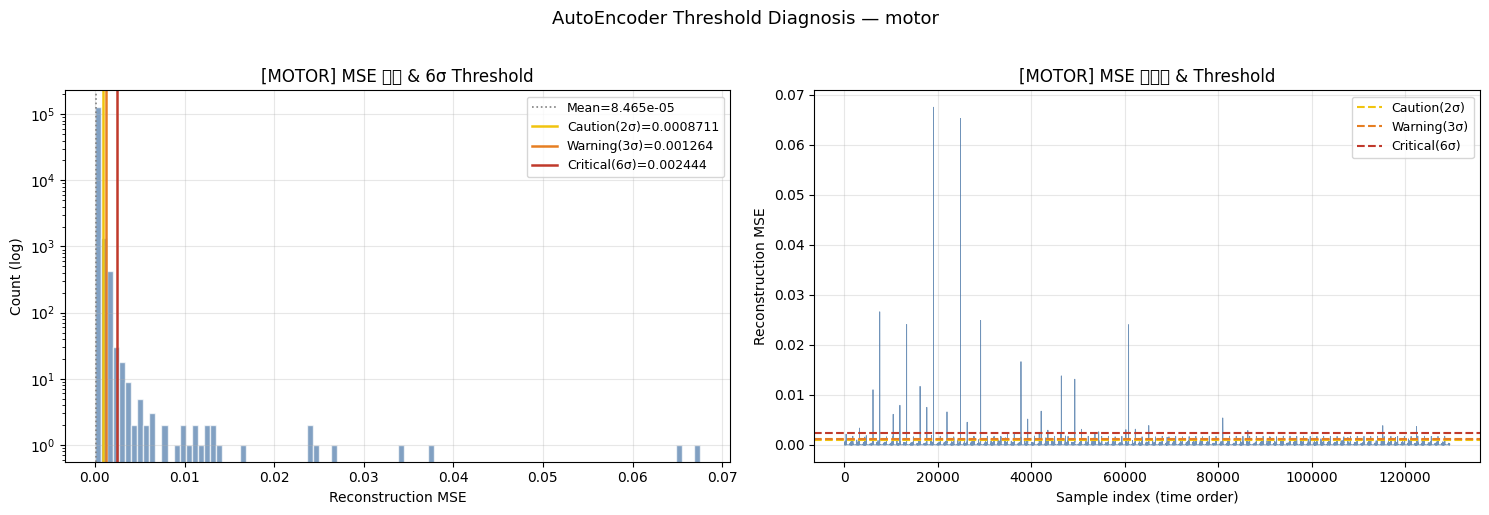

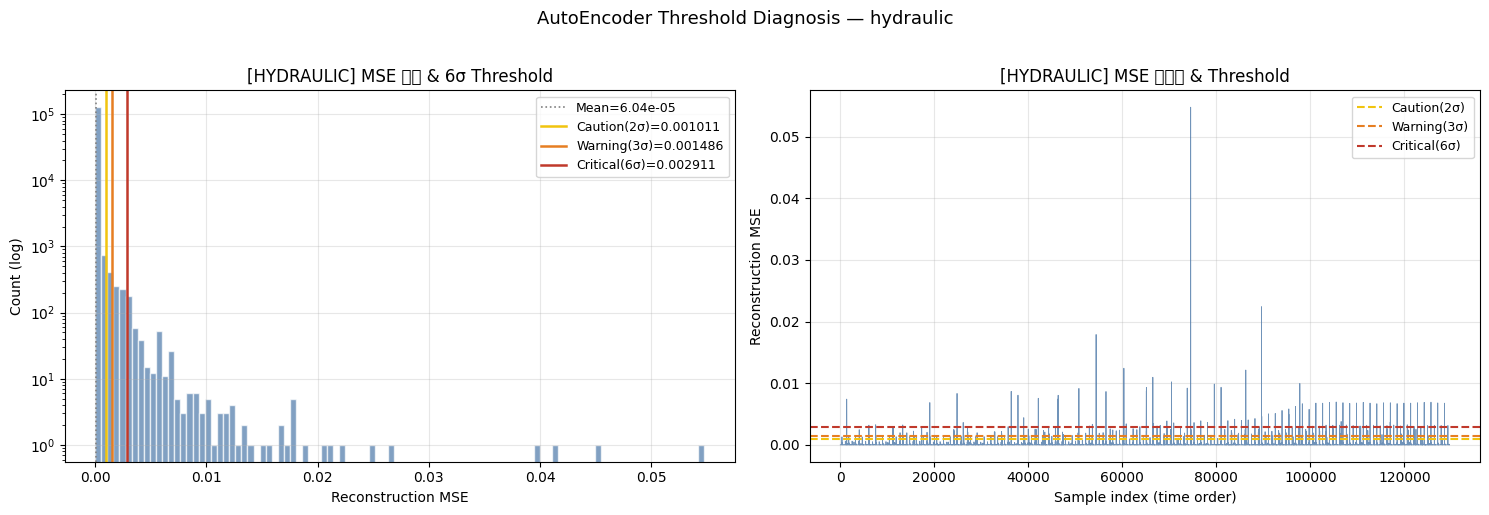

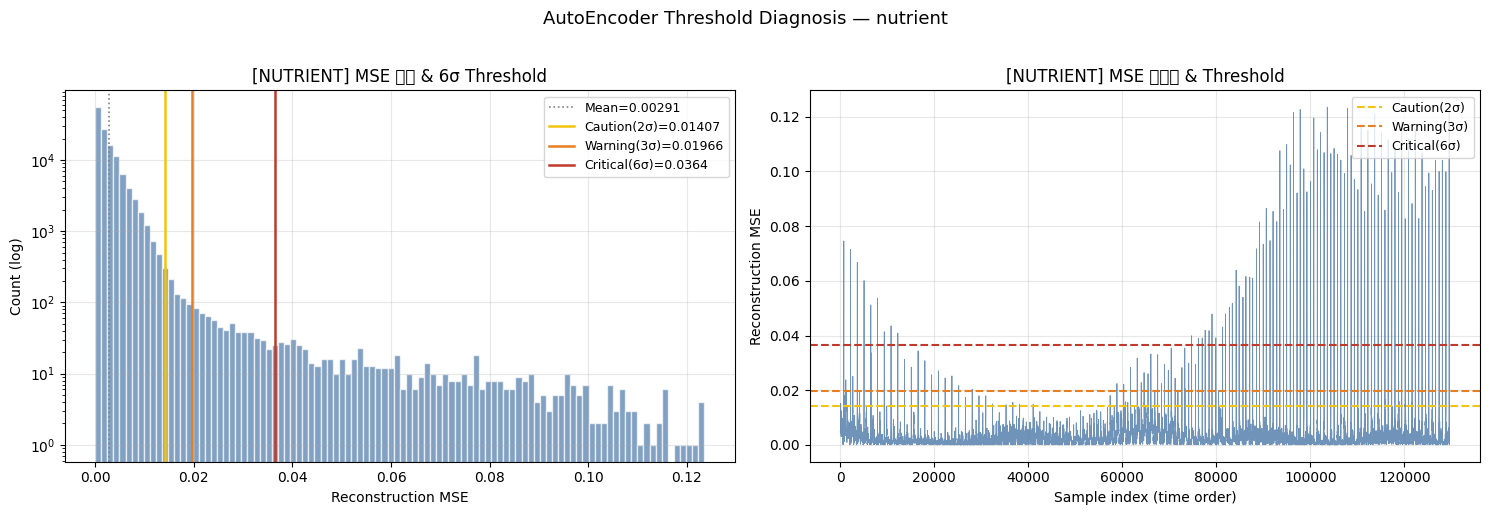

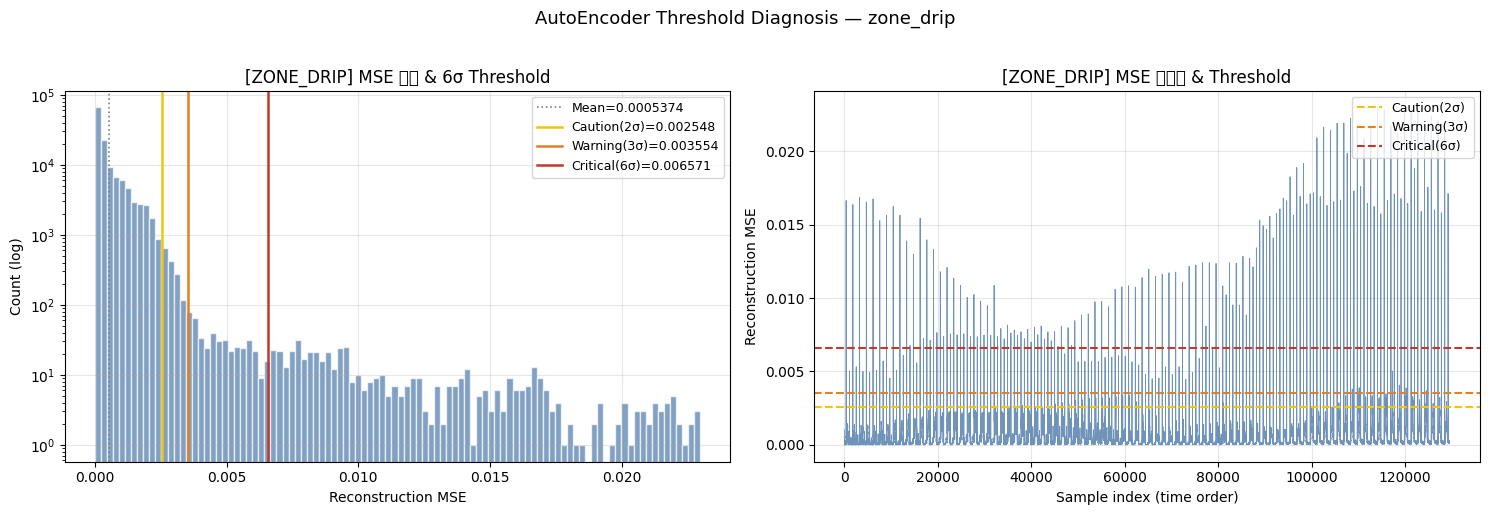

In [25]:
# ==============================================================================
# 📊 [Threshold 시각화] 도메인별 reconstruction error 분포 + 시계열 + 6σ 임계값
# ==============================================================================
import matplotlib.pyplot as plt

def plot_threshold(mse_scores, thresholds, model_name):
    """
    왼쪽: reconstruction error 히스토그램 (log y) + caution/warning/critical 수직선
    오른쪽: 시간순 reconstruction error 라인 + 동일한 threshold 가로선
    """
    t_caut = thresholds["caution"]
    t_warn = thresholds["warning"]
    t_crit = thresholds["critical"]
    t_mean = thresholds["mean"]

    fig, (ax_hist, ax_ts) = plt.subplots(1, 2, figsize=(15, 5))

    # --- Left: histogram ---
    ax_hist.hist(mse_scores, bins=100, color="#4C78A8", alpha=0.7, edgecolor="white")
    ax_hist.set_yscale("log")
    ax_hist.axvline(t_mean, color="gray", linestyle=":", lw=1.2, label=f"Mean={t_mean:.4g}")
    ax_hist.axvline(t_caut, color="#F1C40F", lw=1.8, label=f"Caution(2σ)={t_caut:.4g}")
    ax_hist.axvline(t_warn, color="#E67E22", lw=1.8, label=f"Warning(3σ)={t_warn:.4g}")
    ax_hist.axvline(t_crit, color="#C0392B", lw=1.8, label=f"Critical(6σ)={t_crit:.4g}")
    ax_hist.set_xlabel("Reconstruction MSE")
    ax_hist.set_ylabel("Count (log)")
    ax_hist.set_title(f"[{model_name.upper()}] MSE 분포 & 6σ Threshold")
    ax_hist.legend(loc="upper right", fontsize=9)
    ax_hist.grid(True, alpha=0.3)

    # --- Right: time series ---
    ax_ts.plot(mse_scores, color="#4C78A8", lw=0.6, alpha=0.8)
    ax_ts.axhline(t_caut, color="#F1C40F", lw=1.5, linestyle="--", label="Caution(2σ)")
    ax_ts.axhline(t_warn, color="#E67E22", lw=1.5, linestyle="--", label="Warning(3σ)")
    ax_ts.axhline(t_crit, color="#C0392B", lw=1.5, linestyle="--", label="Critical(6σ)")
    ax_ts.set_xlabel("Sample index (time order)")
    ax_ts.set_ylabel("Reconstruction MSE")
    ax_ts.set_title(f"[{model_name.upper()}] MSE 시계열 & Threshold")
    ax_ts.legend(loc="upper right", fontsize=9)
    ax_ts.grid(True, alpha=0.3)

    fig.suptitle(f"AutoEncoder Threshold Diagnosis — {model_name}", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()


for name, result in all_results.items():
    if result is None:
        continue
    mse_scores, thresholds = result
    plot_threshold(mse_scores, thresholds, name)
